# End-to-End Fraud Detection Modeling & Risk Decisioning System

**Dataset:** IEEE-CIS Fraud Detection (Vesta) · **Approach:** Rules + ML + Anomaly Detection → Calibrated Risk Score → Decision Engine

---

### What this notebook is
This is a single, self-contained, **teaching** notebook. It builds a complete fraud-detection *system* — not just a classifier — the way a real Credit & Fraud Risk (CFR) team would: point-in-time feature engineering, a hybrid rules + ML + anomaly stack, calibrated probabilities, cost-based decision thresholds, SHAP explainability, error analysis, and monitoring.

### How to read it
Every substantive step follows a fixed pattern so you can learn it cell-by-cell and defend it in an interview:

1. **Concept** — what & why, in plain English
2. **Method** — the technique and why it fits here
3. **Code** — the implementation
4. **Result** — what the output shows
5. **Interpretation & intuition** — meaning, intuition, pitfalls
6. **Interview angle** — the 1–2 lines you'd actually say

### The system at a glance
```
Raw transactions -> Data quality/EDA -> Temporal split ->
Point-in-time features -> [Rules | LR/XGBoost/LightGBM | Isolation Forest] ->
Evaluation & champion -> Calibration -> Risk score (0-1000) ->
SHAP reason codes -> Decision engine (APPROVE / CHALLENGE / DECLINE) -> Monitoring
```

> **Note:** Run cells **top to bottom on a fresh kernel**. Later cells depend on earlier ones. The plan this notebook implements is in `PROJECT_PLAN.md`.


## Phase 0 — Setup & Reproducibility

**Concept.** Before any analysis, we fix the environment so results are *reproducible*. In risk modeling, a result you can't reproduce is a result you can't defend.

**Method.** Import the libraries once, set a single global `SEED` used everywhere a randomness knob exists (splits, model training, resampling, bootstrap), and centralize configuration (paths, cost assumptions, window sizes) in one place so there are no "magic numbers" scattered through the notebook.

**Interview angle.** *"I fix seeds and centralize config so the whole pipeline is reproducible end-to-end — the same discipline a model-risk team expects before sign-off."*


In [1]:
# --- Core imports -----------------------------------------------------------
import os
import gc
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 4.5)

# --- Reproducibility --------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# --- Central configuration --------------------------------------------------
CONFIG = {
    "seed": SEED,
    "data_dir": Path("data"),                 # where the IEEE-CIS CSVs live
    "artifacts_dir": Path("artifacts"),        # saved model/pipeline/plots
    # Time-based split fractions (by transaction time, not random):
    "split_fracs": {"train": 0.70, "calib": 0.10, "valid": 0.10, "test": 0.10},
    # Business cost assumptions (illustrative $ values; documented, not eyeballed):
    "costs": {
        "avg_fraud_loss": 150.0,       # $ lost per missed fraud (amount + chargeback)
        "fp_friction": 5.0,            # $ cost of wrongly declining a good customer
        "challenge_cost": 0.50,        # $ cost of a step-up (OTP/push) or review touch
        "p_legit_pass": 0.95,          # legit users who clear a challenge
        "p_legit_abandon_loss": 25.0,  # $ lost revenue when a legit user abandons
        "p_fraud_pass": 0.10,          # fraudsters who beat a challenge
    },
    "review_capacity_rate": 0.05,      # max share of traffic we can send to CHALLENGE
    "velocity_windows": ["1h", "6h", "24h", "7d"],
    "topk_for_precision": 1000,        # investigator review budget for Precision@K
}
CONFIG["artifacts_dir"].mkdir(exist_ok=True)

print("Environment ready.")
print("pandas", pd.__version__, "| numpy", np.__version__, "| seed", SEED)


Environment ready.
pandas 2.3.3 | numpy 2.5.2 | seed 42


## Phase 1a — Data Acquisition (download the IEEE-CIS dataset)

**Concept.** The IEEE-CIS Fraud Detection data is hosted on Kaggle. We want the notebook to **fetch it programmatically** so it's reproducible, with a clear manual fallback if credentials aren't set up.

**Method.** We use the official **Kaggle API**. The cell below:
1. checks whether the CSVs already exist in `data/` (if so, it does nothing);
2. otherwise tries `kaggle competitions download -c ieee-fraud-detection` and unzips into `data/`;
3. if the API/credentials are missing, it prints exact manual steps instead of crashing.

**One-time Kaggle API setup (if you haven't):**
- `pip install kaggle`
- Create an API token: Kaggle → *Account* → *Create New API Token* → downloads `kaggle.json`
- Put `kaggle.json` in `%USERPROFILE%\.kaggle\` (Windows) or `~/.kaggle/` (Mac/Linux)
- Accept the competition rules once on the [competition page](https://www.kaggle.com/c/ieee-fraud-detection/rules)

**Interview angle.** *"Data access is scripted and reproducible, with a graceful fallback — not a manual 'download it somewhere' step."*


In [5]:
# --- Download IEEE-CIS data (idempotent, with graceful fallback) -------------
import subprocess, zipfile

DATA_DIR = CONFIG["data_dir"]
DATA_DIR.mkdir(exist_ok=True)

REQUIRED = ["train_transaction.csv", "train_identity.csv"]
COMPETITION = "ieee-fraud-detection"

def _have_required():
    return all((DATA_DIR / f).exists() for f in REQUIRED)

def _manual_instructions():
    print("\n[Manual fallback] Could not auto-download. Do ONE of the following:")
    print("  A) Kaggle API:")
    print(f"       pip install kaggle")
    print(f"       kaggle competitions download -c {COMPETITION} -p \"{DATA_DIR.resolve()}\"")
    print(f"       # then unzip the archive into: {DATA_DIR.resolve()}")
    print("  B) Website: https://www.kaggle.com/c/ieee-fraud-detection/data")
    print(f"       download all, unzip, and place the CSVs in: {DATA_DIR.resolve()}")

if _have_required():
    print(f"Data already present in '{DATA_DIR.resolve()}'. Skipping download.")
else:
    print("Required CSVs not found. Attempting Kaggle API download...")
    try:
        # Requires `pip install kaggle` and kaggle.json credentials in place.
        subprocess.run(
            ["kaggle", "competitions", "download", "-c", COMPETITION, "-p", str(DATA_DIR)],
            check=True,
        )
        # Unzip everything we just downloaded.
        for zpath in DATA_DIR.glob("*.zip"):
            with zipfile.ZipFile(zpath, "r") as zf:
                zf.extractall(DATA_DIR)
            print(f"Unzipped {zpath.name}")
        if _have_required():
            print("Download + unzip complete.")
        else:
            _manual_instructions()
    except Exception as e:
        print(f"Auto-download failed: {type(e).__name__}: {e}")
        _manual_instructions()

# Hard stop with a clear message if data is still missing, so later cells don't
# fail with a cryptic error.
assert _have_required(), (
    f"Place {REQUIRED} in '{DATA_DIR.resolve()}' before continuing (see instructions above)."
)
print("\nFiles available:", [p.name for p in DATA_DIR.glob('*.csv')])


Data already present in 'E:\Fraud Detection Modeling Project\data'. Skipping download.

Files available: ['test_identity.csv', 'test_transaction.csv', 'train_identity.csv', 'train_transaction.csv']


## Phase 1b — Load, Merge & Reduce Memory

**Concept.** IEEE-CIS ships as two tables: `train_transaction` (the transactions + label) and `train_identity` (device/browser info available for only ~24% of transactions). We join them on `TransactionID`. The combined frame is wide (~430 columns) and memory-heavy, so we **downcast** numeric types.

**Method.**
- **Left join** transaction ← identity (keep every transaction; identity is a bonus signal). Missing identity is *itself informative* and becomes a feature later.
- **Memory reduction:** downcast float64→float32 and int64→smallest int. On ~590k rows this roughly halves RAM and speeds everything up, with no modeling loss.

**Interview angle.** *"Only ~24% of rows have identity data — I treat that missingness as a signal rather than dropping those rows, and I downcast dtypes to keep the wide frame efficient."*


In [6]:
def reduce_mem_usage(df, verbose=True):
    """Downcast numeric columns to the smallest safe dtype to save memory."""
    start = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        c = df[col]
        if pd.api.types.is_numeric_dtype(c) and not pd.api.types.is_bool_dtype(c):
            if pd.api.types.is_integer_dtype(c):
                df[col] = pd.to_numeric(c, downcast="integer")
            else:
                df[col] = pd.to_numeric(c, downcast="float")
    end = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f"Memory: {start:,.1f} MB -> {end:,.1f} MB ({100*(start-end)/start:,.1f}% smaller)")
    return df

# Load
txn = pd.read_csv(DATA_DIR / "train_transaction.csv")
idn = pd.read_csv(DATA_DIR / "train_identity.csv")
print(f"train_transaction: {txn.shape}  |  train_identity: {idn.shape}")

# Merge (left join keeps all transactions)
df = txn.merge(idn, how="left", on="TransactionID")
del txn, idn
gc.collect()

df = reduce_mem_usage(df)
print(f"\nMerged dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Identity match rate: {df['DeviceType'].notna().mean():.1%}")
df.head(3)


train_transaction: (590540, 394)  |  train_identity: (144233, 41)
Memory: 2,514.0 MB -> 1,603.3 MB (36.2% smaller)

Merged dataset: 590,540 rows x 434 columns
Identity match rate: 23.8%


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,...,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5000,W,13926,NaN,150.0000,discover,142.0000,credit,315.0000,87.0000,19.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,2.0000,0.0000,1.0000,1.0000,14.0000,NaN,13.0000,NaN,NaN,NaN,NaN,NaN,NaN,13.0000,13.0000,NaN,NaN,NaN,0.0000,T,T,T,M2,F,T,NaN,NaN,NaN,1.0000,1.0000,1.0000,1.0000,1.0000,...,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0000,W,2755,404.0000,150.0000,mastercard,102.0000,credit,325.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0000,W,4663,490.0000,150.0000,visa,166.0000,debit,330.0000,87.0000,287.0000,NaN,outlook.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000,315.0000,NaN,NaN,NaN,315.0000,T,T,T,M0,F,F,F,F,F,1.0000,1.0000,1.0000,1.0000,1.0000,...,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Phase 2 — Data Quality & EDA

**Concept.** EDA is not "make some plots." The goal is to answer one question: **what does fraud actually look like in this data?** Every finding must feed forward into a feature, a rule, or a modeling choice.

We cover, in order:
1. **Schema & data dictionary** — types, cardinality, feature families
2. **Missingness** — and whether missingness itself predicts fraud
3. **Target / imbalance** — the base rate we must design around
4. **Amount behaviour** — fraud vs legit
5. **Temporal behaviour** — fraud over time
6. **Categorical fraud rates** — which segments are risky

### 2.1 Schema, cardinality & missingness

**Method.** Summarize dtype, unique-count, and missing-% per column, and check whether "identity present" correlates with fraud (a missingness-as-signal test).

**Interview angle.** *"I profiled types, cardinality, and missingness first — including testing whether missingness itself is predictive, which it often is in fraud."*


In [7]:
TARGET = "isFraud"

# --- Compact data dictionary / profile --------------------------------------
profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(dropna=True),
    "missing_pct": df.isna().mean().mul(100).round(2),
})
profile["family"] = np.select(
    [
        profile.index.str.startswith("V"),
        profile.index.str.startswith("C"),
        profile.index.str.startswith("D"),
        profile.index.str.startswith("M"),
        profile.index.str.startswith("id_"),
        profile.index.str.startswith("card"),
        profile.index.str.startswith("addr"),
        profile.index.str.contains("email"),
    ],
    ["V", "C", "D", "M", "identity", "card", "addr", "email"],
    default="other",
)
print("Columns by family:")
print(profile["family"].value_counts())
print(f"\nColumns with >50% missing: {(profile['missing_pct'] > 50).sum()} of {len(profile)}")

# --- Missingness-as-signal quick test ---------------------------------------
overall_fraud = df[TARGET].mean()
id_present = df["DeviceType"].notna()
print(f"\nOverall fraud rate:                 {overall_fraud:.3%}")
print(f"Fraud rate | identity PRESENT:      {df.loc[id_present, TARGET].mean():.3%}")
print(f"Fraud rate | identity MISSING:      {df.loc[~id_present, TARGET].mean():.3%}")

profile.head(15)


Columns by family:
family
V           339
identity     38
D            17
C            14
M             9
other         7
card          6
email         2
addr          2
Name: count, dtype: int64

Columns with >50% missing: 214 of 434

Overall fraud rate:                 3.499%
Fraud rate | identity PRESENT:      7.962%
Fraud rate | identity MISSING:      2.102%


,dtype,n_unique,missing_pct,family
TransactionID,int32,590540,0.0000,other
isFraud,int8,2,0.0000,other
TransactionDT,int32,573349,0.0000,other
TransactionAmt,float32,20902,0.0000,other
ProductCD,object,5,0.0000,other
card1,int16,13553,0.0000,card
card2,float32,500,1.5100,card
card3,float32,114,0.2700,card
card4,object,4,0.2700,card
card5,float32,119,0.7200,card


### 2.2 Target & class imbalance

**Concept.** Fraud is rare (~3.5%). This single fact drives almost every later decision: it's why we won't use accuracy, why we prefer **PR-AUC**, why we use class weighting, and why the decision threshold matters more than the raw model.

**Method.** Count the classes and visualize the imbalance.

**Interview angle.** *"At a ~3.5% base rate, a 'predict-never-fraud' model is 96.5% accurate and useless — that's why I anchor on PR-AUC and cost, not accuracy."*


Class counts:
  Legit (0): 569,877
  Fraud (1): 20,663
  Fraud rate: 3.499%
  Imbalance ratio: 1 fraud per 28 legit


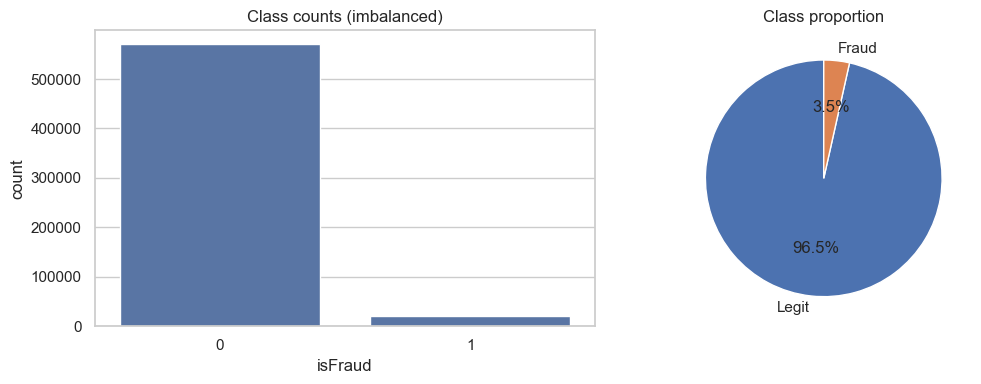

In [8]:
counts = df[TARGET].value_counts().sort_index()
print("Class counts:")
print(f"  Legit (0): {counts.get(0,0):,}")
print(f"  Fraud (1): {counts.get(1,0):,}")
print(f"  Fraud rate: {df[TARGET].mean():.3%}")
print(f"  Imbalance ratio: 1 fraud per {counts.get(0,0)/max(counts.get(1,1),1):,.0f} legit")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x=df[TARGET], ax=ax[0])
ax[0].set_title("Class counts (imbalanced)"); ax[0].set_xlabel("isFraud")
ax[1].pie(counts, labels=["Legit", "Fraud"], autopct="%1.1f%%", startangle=90,
          colors=["#4C72B0", "#DD8452"])
ax[1].set_title("Class proportion")
plt.tight_layout(); plt.show()


### 2.3 Transaction amount — fraud vs legit

**Concept.** Does fraud have a different *monetary signature*? Fraudsters often either test with tiny amounts or cash out with large ones, so the amount distribution frequently differs from legitimate spend.

**Method.** Compare summary statistics and the (log-scaled) distribution of `TransactionAmt` for fraud vs legit. We log-scale because amounts are heavily right-skewed.

**Interview angle.** *"I compared the amount distribution by class on a log scale because raw amounts are skewed; differences here justify amount-deviation features later."*


TransactionAmt by class:
          mean  median      std      p95        p99         max
Legit 134.5117 68.5000 239.3951 435.0000 1,104.0000 31,937.3906
Fraud 149.2448 75.0000 232.2122 500.0000   994.0000  5,191.0000


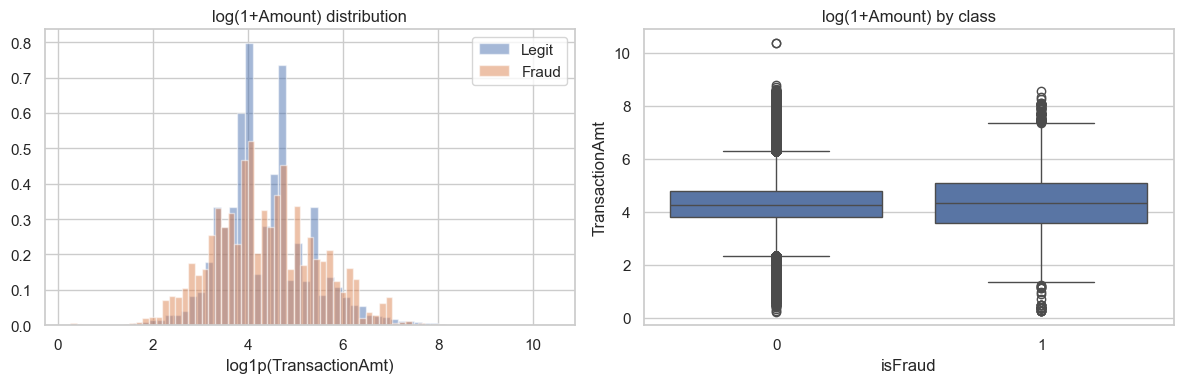

In [9]:
amt_stats = df.groupby(TARGET)["TransactionAmt"].agg(
    ["mean", "median", "std",
     lambda s: s.quantile(0.95), lambda s: s.quantile(0.99), "max"]
)
amt_stats.columns = ["mean", "median", "std", "p95", "p99", "max"]
amt_stats.index = ["Legit", "Fraud"]
print("TransactionAmt by class:")
print(amt_stats)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for label, sub in df.groupby(TARGET):
    ax[0].hist(np.log1p(sub["TransactionAmt"]), bins=60, alpha=0.5,
               density=True, label="Fraud" if label == 1 else "Legit")
ax[0].set_title("log(1+Amount) distribution"); ax[0].set_xlabel("log1p(TransactionAmt)")
ax[0].legend()
sns.boxplot(x=df[TARGET], y=np.log1p(df["TransactionAmt"]), ax=ax[1])
ax[1].set_title("log(1+Amount) by class"); ax[1].set_xlabel("isFraud")
plt.tight_layout(); plt.show()


### 2.4 Temporal behaviour

**Concept.** `TransactionDT` is a time offset in **seconds** from a fixed reference. Fraud is often concentrated at certain hours (e.g., overnight) when victims aren't watching. Understanding time also validates that a **time-based split** is meaningful.

**Method.** Derive an hour-of-day and day index from `TransactionDT`, then plot the fraud *rate* (not count) by hour, and the fraud rate over the dataset's timeline.

**Interview angle.** *"`TransactionDT` is a seconds offset, so I derived hour/day and looked at fraud **rate** by hour — and I checked fraud rate over time to confirm a temporal split is both valid and necessary."*


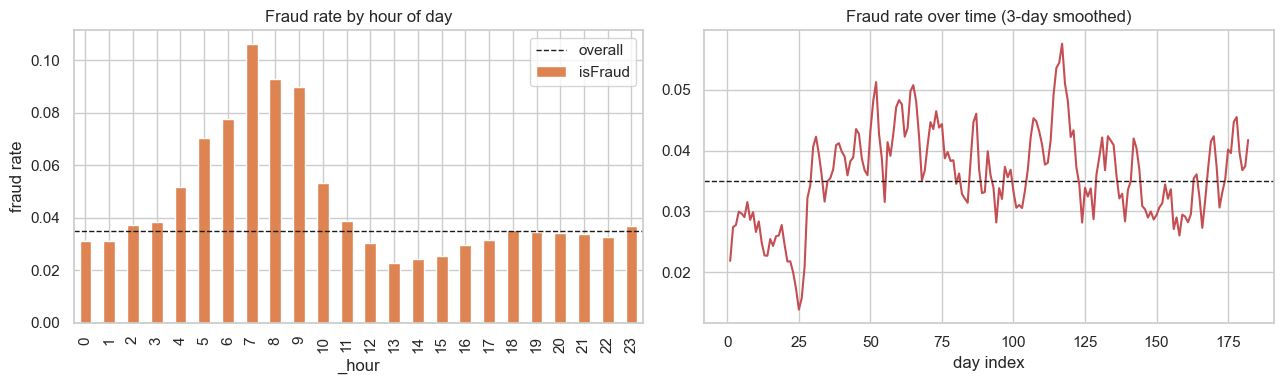

Peak-hour fraud rate: 10.61% at hour 7
Low-hour  fraud rate: 2.29% at hour 13
Timeline spans ~182 days -> a time-based split is well-defined.


In [10]:
# Derive lightweight time fields for EDA (reused as features later)
SECONDS_PER_DAY = 24 * 3600
df["_hour"] = (df["TransactionDT"] // 3600) % 24
df["_day"] = (df["TransactionDT"] // SECONDS_PER_DAY).astype(int)

hour_rate = df.groupby("_hour")[TARGET].mean()
day_rate = df.groupby("_day")[TARGET].mean()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
hour_rate.plot(kind="bar", ax=ax[0], color="#DD8452")
ax[0].axhline(df[TARGET].mean(), color="k", ls="--", lw=1, label="overall")
ax[0].set_title("Fraud rate by hour of day"); ax[0].set_ylabel("fraud rate"); ax[0].legend()
day_rate.rolling(3, min_periods=1).mean().plot(ax=ax[1], color="#C44E52")
ax[1].axhline(df[TARGET].mean(), color="k", ls="--", lw=1)
ax[1].set_title("Fraud rate over time (3-day smoothed)"); ax[1].set_xlabel("day index")
plt.tight_layout(); plt.show()

print(f"Peak-hour fraud rate: {hour_rate.max():.2%} at hour {hour_rate.idxmax()}")
print(f"Low-hour  fraud rate: {hour_rate.min():.2%} at hour {hour_rate.idxmin()}")
print(f"Timeline spans ~{df['_day'].max()} days -> a time-based split is well-defined.")


### 2.5 Categorical fraud rates — where does risk concentrate?

**Concept.** Some product types, card types, email domains, and devices carry much higher fraud rates than others. These high-risk segments are exactly what we'll encode as features and codify as rules.

**Method.** For key categoricals, show the fraud rate per category (only for reasonably frequent values), sorted, against the overall base rate.

**Interview angle.** *"I ranked fraud rate by category (with a support filter) to find high-risk segments — these directly seed both my encodings and my rule engine."*


In [11]:
def fraud_rate_by_cat(col, min_support=500, top=8):
    g = df.groupby(col)[TARGET].agg(["mean", "count"])
    g = g[g["count"] >= min_support].sort_values("mean", ascending=False)
    return g.head(top)

cat_cols = [c for c in ["ProductCD", "card4", "card6", "P_emaildomain", "DeviceType"]
            if c in df.columns]

for c in cat_cols:
    print(f"\n=== Fraud rate by {c} (overall {df[TARGET].mean():.2%}) ===")
    print(fraud_rate_by_cat(c).rename(columns={"mean": "fraud_rate", "count": "n"}))



=== Fraud rate by ProductCD (overall 3.50%) ===
           fraud_rate       n
ProductCD                    
C              0.1169   68519
S              0.0590   11628
H              0.0477   33024
R              0.0378   37699
W              0.0204  439670

=== Fraud rate by card4 (overall 3.50%) ===
                  fraud_rate       n
card4                               
discover              0.0773    6651
visa                  0.0348  384767
mastercard            0.0343  189217
american express      0.0287    8328

=== Fraud rate by card6 (overall 3.50%) ===
        fraud_rate       n
card6                     
credit      0.0668  148986
debit       0.0243  439938

=== Fraud rate by P_emaildomain (overall 3.50%) ===
               fraud_rate       n
P_emaildomain                    
mail.com           0.1896     559
outlook.com        0.0946    5096
live.com.mx        0.0547     749
hotmail.com        0.0530   45250
gmail.com          0.0435  228355
icloud.com         0.0314    6

## Phase 3 — Temporal Split & the Leakage Doctrine

**Concept.** In production you train on the **past** and score the **future**. A random split leaks future information into training and inflates your scores. So we sort by `TransactionDT` and cut the timeline into four ordered blocks:

```
TIME ─────────────────────────────────────────────────────────────▶
|      TRAIN (70%)      | CALIB (10%) | VALID (10%) |  OOT TEST (10%) |
        (fit models)      (calibrate)  (tune/thresh)  (final, untouched)
```

- **Train** — fit models and learn encodings.
- **Calibration** — fit the probability calibrator (never on train or test).
- **Validation** — pick hyperparameters and decision thresholds.
- **Out-of-Time (OOT) Test** — touched **once**, for the final honest number.

**The leakage doctrine (governs all feature engineering):** for a transaction at time *T*, every engineered feature may use **only data strictly before *T***. Any encoding learned from labels is fit on **train only**.

**Interview angle.** *"I use a time-ordered train/calibration/validation/OOT-test split — never a random split — and a strict point-in-time rule for every historical feature. This is the single biggest thing that separates a real fraud model from a leaky one."*


In [12]:
# Sort strictly by time, then cut ordered blocks by cumulative fraction.
df = df.sort_values("TransactionDT").reset_index(drop=True)

fr = CONFIG["split_fracs"]
n = len(df)
i_train = int(n * fr["train"])
i_calib = int(n * (fr["train"] + fr["calib"]))
i_valid = int(n * (fr["train"] + fr["calib"] + fr["valid"]))

split = np.empty(n, dtype=object)
split[:i_train] = "train"
split[i_train:i_calib] = "calib"
split[i_calib:i_valid] = "valid"
split[i_valid:] = "test"
df["_split"] = split

summary = (df.groupby("_split")
             .agg(rows=("TransactionID", "size"),
                  fraud_rate=(TARGET, "mean"),
                  dt_min=("TransactionDT", "min"),
                  dt_max=("TransactionDT", "max"))
             .reindex(["train", "calib", "valid", "test"]))
print("Time-ordered split (note dt ranges do not overlap):")
print(summary)

# Confirm no time overlap between consecutive blocks (a leakage guardrail).
order = ["train", "calib", "valid", "test"]
for a, b in zip(order, order[1:]):
    assert summary.loc[a, "dt_max"] <= summary.loc[b, "dt_min"], f"time overlap {a}->{b}!"
print("\nGuardrail passed: blocks are strictly time-ordered (no overlap).")


Time-ordered split (note dt ranges do not overlap):
          rows  fraud_rate    dt_min    dt_max
_split                                        
train   413378      0.0352     86400  10437996
calib    59053      0.0349  10438003  12192743
valid    59055      0.0313  12192842  13990904
test     59054      0.0375  13990941  15811131

Guardrail passed: blocks are strictly time-ordered (no overlap).


## Phase 4 — Feature Engineering (point-in-time-safe)

Feature engineering is where a fraud model is won or lost. We build five groups, all obeying the leakage doctrine:

1. **Static transaction features** (safe per-row): `log(amount)`, cents part, amount buckets, hour/weekday/night, cyclical time.
2. **Behavioural history** (per card, backward-looking): prior count, prior mean/std amount, amount-vs-history ratio & z-score, tenure, time-since-last.
3. **Velocity** (trailing time windows, strictly backward): #transactions in 1h/6h/24h/7d.
4. **Encodings** (label-based fit on **train only**): frequency encoding + out-of-fold target encoding + cross-field mismatch flags + a graph-lite fraud-ring proxy.
5. **Cold-start handling**: unseen categories / new entities get safe defaults instead of NaN/crash.

### 4.1 Static transaction features

**Concept.** Features computable from a single row with no history — always leakage-safe. Amounts are skewed (→ log), the cents part can reveal automated/round-number fraud, and time is cyclical (23:00 is close to 00:00).

**Interview angle.** *"I separate static per-row features from historical ones — the static ones can never leak, so I get them out of the way first."*


In [13]:
# --- Static, per-row transaction features (leakage-safe) ---------------------
df["amt_log"] = np.log1p(df["TransactionAmt"])
df["amt_cents"] = (df["TransactionAmt"] - np.floor(df["TransactionAmt"])).round(2)
df["amt_is_round"] = (df["amt_cents"] == 0).astype("int8")
df["amt_bucket"] = pd.cut(df["TransactionAmt"],
                          bins=[-1, 25, 100, 250, 1000, np.inf],
                          labels=[0, 1, 2, 3, 4]).astype("int16")

# Time features (from the seconds-offset TransactionDT)
df["hour"] = df["_hour"].astype("int16")
df["dayofweek"] = ((df["TransactionDT"] // SECONDS_PER_DAY) % 7).astype("int16")
df["is_night"] = df["hour"].isin([0, 1, 2, 3, 4, 5]).astype("int8")
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype("int8")
# Cyclical encodings so the model sees 23:00 and 00:00 as adjacent
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

print("Static features added.")
df[["TransactionAmt", "amt_log", "amt_cents", "amt_is_round", "amt_bucket",
    "hour", "dayofweek", "is_night", "hour_sin", "hour_cos"]].head()


Static features added.


,TransactionAmt,amt_log,amt_cents,amt_is_round,amt_bucket,hour,dayofweek,is_night,hour_sin,hour_cos
0,68.5000,4.2413,0.5000,0,1,0,1,1,0.0000,1.0000
1,29.0000,3.4012,0.0000,1,1,0,1,1,0.0000,1.0000
2,59.0000,4.0943,0.0000,1,1,0,1,1,0.0000,1.0000
3,50.0000,3.9318,0.0000,1,1,0,1,1,0.0000,1.0000
4,50.0000,3.9318,0.0000,1,1,0,1,1,0.0000,1.0000


### 4.2 Behavioural history & velocity (strictly backward-looking)

**Concept.** "How unusual is this transaction *for this card*?" A $1,500 charge is normal for some cards and a red flag for others. And fraud often arrives in **bursts** — many transactions in minutes. Both require per-card history using **only prior rows**.

**Method.**
- **Behavioural history** via cumulative sums that *exclude the current row*: prior count, prior mean/std, `amount / prior_mean`, z-score vs history, tenure (time since first seen), time since last transaction.
- **Velocity** via time-windowed rolling counts with `closed="left"` (excludes the current transaction), so a transaction never counts itself.
- **Z-score stability:** cards with 1–2 prior transactions have a near-zero historical std, so a raw z-score explodes (std in the hundreds, max in the tens of thousands). We **floor the denominator** and **clip** the z-score / ratio so rare-history entities stay in a sane range. Trees are somewhat robust to this; Logistic Regression and Isolation Forest are not.

We anchor on `card1` (the primary card identifier). The exact same pattern generalizes to email/address entities.

**Interview angle.** *"All history features use cumulative sums that exclude the current row, and velocity uses `closed='left'` rolling windows — so a transaction can never see itself or the future. That's point-in-time correctness made concrete."*


In [14]:
# df is already sorted by TransactionDT (Phase 3). Anchor entity = card1.
ENTITY = "card1"
g = df.groupby(ENTITY, sort=False)

# --- Prior count & tenure ---------------------------------------------------
df[f"{ENTITY}_prior_cnt"] = g.cumcount()                       # # of earlier txns
df[f"{ENTITY}_first_dt"] = g["TransactionDT"].transform("min")
df[f"{ENTITY}_tenure"] = df["TransactionDT"] - df[f"{ENTITY}_first_dt"]
df[f"{ENTITY}_time_since_last"] = g["TransactionDT"].diff()     # NaN for first txn

# --- Prior mean / std of amount, EXCLUDING the current row -------------------
df["_amt_sq"] = df["TransactionAmt"] ** 2
prior_sum = g["TransactionAmt"].cumsum() - df["TransactionAmt"]
prior_sqsum = g["_amt_sq"].cumsum() - df["_amt_sq"]
prior_cnt = df[f"{ENTITY}_prior_cnt"].replace(0, np.nan)       # avoid /0 for first txn
prior_mean = prior_sum / prior_cnt
prior_var = (prior_sqsum / prior_cnt) - prior_mean ** 2
prior_std = np.sqrt(prior_var.clip(lower=0))

# Floor std/mean so first-time and near-constant histories don't explode the z-score.
# Clip the resulting features: a 20-sigma spend is already an extreme outlier; 99,000-sigma is noise.
_STD_FLOOR = 1.0          # $1 — amounts are in dollars; tiny std is a sample-size artifact
_MEAN_FLOOR = 0.01
_Z_CLIP, _RATIO_CLIP = 20.0, 50.0
prior_std_safe = prior_std.clip(lower=_STD_FLOOR)
prior_mean_safe = prior_mean.clip(lower=_MEAN_FLOOR)
z = (df["TransactionAmt"] - prior_mean) / prior_std_safe
z = z.where(df[f"{ENTITY}_prior_cnt"] >= 2)          # need ≥2 priors for a real std
df[f"{ENTITY}_amt_prior_mean"] = prior_mean
df[f"{ENTITY}_amt_to_prior_mean"] = (df["TransactionAmt"] / prior_mean_safe).clip(upper=_RATIO_CLIP)
df[f"{ENTITY}_amt_zscore"] = z.clip(-_Z_CLIP, _Z_CLIP)

# --- Velocity: trailing time-window transaction counts (exclude current) -----
# NOTE on alignment: when we pass on="_dt", the rolling result is indexed by the
# timestamp, which repeats (many txns share a second) -> a plain .reindex(df.index)
# would fail on duplicate labels. So we compute on a per-entity, time-sorted copy
# (which also guarantees monotonic windows) and align back by the unique row index.
df["_dt"] = pd.to_datetime(df["TransactionDT"], unit="s")
_vtmp = df[[ENTITY, "_dt", "TransactionDT"]].sort_values([ENTITY, "_dt"], kind="stable")
for w in CONFIG["velocity_windows"]:
    cnt = (_vtmp.groupby(ENTITY).rolling(w, on="_dt", closed="left")["TransactionDT"]
                .count().to_numpy())
    _vtmp[f"_cnt_{w}"] = cnt          # positional assignment into the sorted frame
for w in CONFIG["velocity_windows"]:
    df[f"{ENTITY}_cnt_{w}"] = (_vtmp[f"_cnt_{w}"].reindex(df.index)
                               .fillna(0).astype("int32"))
del _vtmp

df.drop(columns=["_amt_sq"], inplace=True)
print("Behavioural + velocity features added.")
df[[f"{ENTITY}_prior_cnt", f"{ENTITY}_tenure", f"{ENTITY}_time_since_last",
    f"{ENTITY}_amt_to_prior_mean", f"{ENTITY}_amt_zscore"] +
   [f"{ENTITY}_cnt_{w}" for w in CONFIG["velocity_windows"]]].describe().round(3)


Behavioural + velocity features added.


,card1_prior_cnt,card1_tenure,card1_time_since_last,card1_amt_to_prior_mean,card1_amt_zscore,card1_cnt_1h,card1_cnt_6h,card1_cnt_24h,card1_cnt_7d
count,"590,540.0000","590,540.0000","576,987.0000","576,987.0000","566,878.0000","590,540.0000","590,540.0000","590,540.0000","590,540.0000"
mean,"1,263.9080","6,985,008.6270","170,430.5910",1.0860,0.0970,1.4550,6.4260,18.8040,108.6340
std,"2,258.9370","4,671,172.7690","706,424.7640",1.6620,1.8710,5.4990,18.5200,45.6110,187.3440
min,0.0000,0.0000,0.0000,0.0030,-20.0000,0.0000,0.0000,0.0000,0.0000
25%,43.0000,"2,585,288.0000",980.0000,0.3910,-0.4890,0.0000,0.0000,1.0000,5.0000
50%,312.0000,"6,813,428.5000","5,923.0000",0.6570,-0.2850,0.0000,1.0000,5.0000,34.0000
75%,"1,382.0000","10,878,987.2500","58,371.0000",1.1580,0.1430,1.0000,6.0000,19.0000,126.0000
max,"14,931.0000","15,723,755.0000","15,599,674.0000",50.0000,20.0000,191.0000,447.0000,880.0000,"1,678.0000"


### 4.3 Encodings, graph-lite & mismatch flags (label-based → train-only fit)

**Concept.** High-cardinality categoricals (`card1`, `addr1`, email domains) can't go into a model raw. Two safe encodings:
- **Frequency encoding** — how common is this value (fit on train).
- **Target (mean-fraud) encoding** — the historical fraud rate of this value. This is the **easiest place to leak**, so we compute it **out-of-fold within train** (each train row encoded by folds that exclude it) and map non-train rows using the full-train statistics. Unseen values fall back to the global prior.

We also add:
- **Graph-lite ring proxy** — how many distinct cards were seen at an address (train-fit) — a cheap stand-in for the fraud-ring signal a graph model would learn.
- **Cross-field mismatch flags** — e.g. purchaser vs recipient email-domain mismatch — classic manual fraud-analyst heuristics.

**Interview angle.** *"Target encoding is done out-of-fold on train only, with a global-prior fallback for unseen values — so it captures category risk without leaking the label."*


In [15]:
from sklearn.model_selection import KFold

train_mask = (df["_split"] == "train").values
GLOBAL_PRIOR = df.loc[train_mask, TARGET].mean()
print(f"Global prior (train fraud rate) = {GLOBAL_PRIOR:.4f}")

# --- Frequency encoding (TRAIN only; unseen / NaN → 0) ----------------------
FREQ_COLS = [c for c in ["card1", "addr1", "P_emaildomain", "R_emaildomain",
                          "ProductCD", "DeviceInfo"] if c in df.columns]
for col in FREQ_COLS:
    vc = df.loc[train_mask, col].value_counts()          # counts from train rows only
    mapped = df[col].map(vc)                             # future-only values → NaN
    n_unseen = int(mapped.isna().sum() - df[col].isna().sum())
    df[f"{col}_freq"] = mapped.fillna(0).astype("float32")
    print(f"  {col}_freq: train vocabulary={vc.shape[0]:,}  non-train unseen→0: {n_unseen:,}")

# --- Out-of-fold smoothed target encoding -----------------------------------
def target_encode_oof(frame, col, target, tr_mask, n_splits=5, smoothing=20, seed=SEED):
    out = pd.Series(np.nan, index=frame.index, dtype="float64")
    tr_idx = frame.index[tr_mask]
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for fit_pos, val_pos in kf.split(tr_idx):
        fit_i, val_i = tr_idx[fit_pos], tr_idx[val_pos]
        stats = frame.loc[fit_i].groupby(col)[target].agg(["mean", "count"])
        sm = (stats["mean"] * stats["count"] + GLOBAL_PRIOR * smoothing) / (stats["count"] + smoothing)
        out.loc[val_i] = frame.loc[val_i, col].map(sm)
    # Non-train rows use full-train statistics
    stats_full = frame.loc[tr_idx].groupby(col)[target].agg(["mean", "count"])
    sm_full = (stats_full["mean"] * stats_full["count"] + GLOBAL_PRIOR * smoothing) / (stats_full["count"] + smoothing)
    nontrain = ~pd.Series(tr_mask, index=frame.index)
    out.loc[nontrain.values] = frame.loc[nontrain.values, col].map(sm_full)
    return out.fillna(GLOBAL_PRIOR).astype("float32")  # cold-start -> global prior

TE_COLS = [c for c in ["card1", "addr1", "P_emaildomain"] if c in df.columns]
for col in TE_COLS:
    df[f"{col}_te"] = target_encode_oof(df, col, TARGET, train_mask)

# --- Graph-lite ring proxy: distinct cards per address (train-fit) -----------
if "addr1" in df.columns:
    diversity = df.loc[train_mask].groupby("addr1")["card1"].nunique()
    df["addr1_card_diversity"] = df["addr1"].map(diversity).fillna(0).astype("float32")

# --- Cross-field mismatch flags ---------------------------------------------
if {"P_emaildomain", "R_emaildomain"}.issubset(df.columns):
    both = df["P_emaildomain"].notna() & df["R_emaildomain"].notna()
    df["email_mismatch"] = (both & (df["P_emaildomain"] != df["R_emaildomain"])).astype("int8")

print("Encodings, graph-lite proxy, and mismatch flags added.")
new_cols = [f"{c}_te" for c in TE_COLS] + ["addr1_card_diversity", "email_mismatch"]
df[[c for c in new_cols if c in df.columns]].describe().round(4)


Global prior (train fraud rate) = 0.0352
  card1_freq: train vocabulary=12,242  non-train unseen→0: 2,177
  addr1_freq: train vocabulary=318  non-train unseen→0: 19
  P_emaildomain_freq: train vocabulary=59  non-train unseen→0: 0
  R_emaildomain_freq: train vocabulary=60  non-train unseen→0: 0
  ProductCD_freq: train vocabulary=5  non-train unseen→0: 0
  DeviceInfo_freq: train vocabulary=1,546  non-train unseen→0: 788
Encodings, graph-lite proxy, and mismatch flags added.


,card1_te,addr1_te,P_emaildomain_te,addr1_card_diversity,email_mismatch
count,"590,540.0000","590,540.0000","590,540.0000","590,540.0000","590,540.0000"
mean,0.0356,0.0261,0.0360,929.9863,0.0402
std,0.0463,0.0117,0.0142,568.9739,0.1964
min,0.0007,0.0046,0.0027,0.0000,0.0000
25%,0.0119,0.0199,0.0236,500.0000,0.0000
50%,0.0223,0.0250,0.0352,892.0000,0.0000
75%,0.0380,0.0297,0.0440,"1,470.0000",0.0000
max,0.6673,0.3341,0.3445,"1,778.0000",1.0000


### 4.4 Assemble the modelling matrix (+ cold-start policy)

**Concept.** Now we finalize the feature matrix: label-encode any leftover text columns to integer codes (so trees can ingest them), pick the numeric feature set, and split into `X`/`y` per time block.

**Cold-start policy (stated explicitly):** unseen categories were already mapped to the **global prior** (target encoding) or **0** (frequency/diversity). Leftover text codes are **fit on train only**; NaN and categories that never appeared in train map to **-1**. Gradient-boosted trees consume those codes (and NaNs) natively; the Logistic Regression pipeline will impute + scale. So the pipeline never crashes on a value it hasn't seen.

**Interview angle.** *"Every encoder has a defined fallback for unseen values, so the scoring function degrades gracefully on new cards/merchants instead of erroring — the cold-start problem most portfolio projects ignore."*


In [16]:
# --- Label-encode leftover text columns (TRAIN vocabulary only; NaN/unseen → -1)
# Fitting factorize on the full frame would assign codes to test-only categories —
# that is a protocol leak (the training encoder would not have known those values).
obj_cols = [c for c in df.select_dtypes(include="object").columns if c != "_split"]
_tr = df["_split"] == "train"
for c in obj_cols:
    vocab = pd.Index(df.loc[_tr, c].dropna().unique())
    mapping = {val: i for i, val in enumerate(vocab)}
    encoded = df[c].map(mapping)                 # unseen & NaN → NaN
    n_unseen = int(df.loc[~_tr, c].notna().sum() - encoded.loc[~_tr].notna().sum())
    df[c] = encoded.fillna(-1).astype("int32")
    print(f"  {c}: train vocab={len(mapping):,}  non-train unseen→-1: {n_unseen:,}")

# --- Choose feature columns --------------------------------------------------
EXCLUDE = {TARGET, "TransactionID", "TransactionDT", "_hour", "_day", "_dt",
           "_split", f"{ENTITY}_first_dt"}
FEATURES = [c for c in df.columns
            if c not in EXCLUDE and pd.api.types.is_numeric_dtype(df[c])]

# --- Per-split X / y (views into df, memory-friendly) ------------------------
def split_xy(name):
    m = df["_split"] == name
    return df.loc[m, FEATURES], df.loc[m, TARGET]

X_train, y_train = split_xy("train")
X_calib, y_calib = split_xy("calib")
X_valid, y_valid = split_xy("valid")
X_test,  y_test  = split_xy("test")

def is_engineered(c):
    """Features we created (vs raw Vesta columns). Rebuilt whenever FEATURES grows."""
    return (
        c in {"amt_log", "amt_cents", "amt_is_round", "amt_bucket",
              "hour", "dayofweek", "is_night", "is_weekend", "hour_sin", "hour_cos",
              "addr1_card_diversity", "email_mismatch"}
        or c.startswith(f"{ENTITY}_")
        or c.endswith("_freq") or c.endswith("_te")
        or c.startswith("rule_")
    )

ENGINEERED_FEATURES = [c for c in FEATURES if is_engineered(c)]
RAW_FEATURES = [c for c in FEATURES if c not in set(ENGINEERED_FEATURES)]

print(f"Feature count: {len(FEATURES)}  (engineered={len(ENGINEERED_FEATURES)}, raw Vesta={len(RAW_FEATURES)})")
for nm, (X, y) in {"train": (X_train, y_train), "calib": (X_calib, y_calib),
                   "valid": (X_valid, y_valid), "test": (X_test, y_test)}.items():
    print(f"  {nm:>5}: X={X.shape}, fraud_rate={y.mean():.3%}")


  ProductCD: train vocab=5  non-train unseen→-1: 0
  card4: train vocab=4  non-train unseen→-1: 0
  card6: train vocab=4  non-train unseen→-1: 0
  P_emaildomain: train vocab=59  non-train unseen→-1: 0
  R_emaildomain: train vocab=60  non-train unseen→-1: 0
  M1: train vocab=2  non-train unseen→-1: 0
  M2: train vocab=2  non-train unseen→-1: 0
  M3: train vocab=2  non-train unseen→-1: 0
  M4: train vocab=3  non-train unseen→-1: 0
  M5: train vocab=2  non-train unseen→-1: 0
  M6: train vocab=2  non-train unseen→-1: 0
  M7: train vocab=2  non-train unseen→-1: 0
  M8: train vocab=2  non-train unseen→-1: 0
  M9: train vocab=2  non-train unseen→-1: 0
  id_12: train vocab=2  non-train unseen→-1: 0
  id_15: train vocab=3  non-train unseen→-1: 0
  id_16: train vocab=2  non-train unseen→-1: 0
  id_23: train vocab=3  non-train unseen→-1: 0
  id_27: train vocab=2  non-train unseen→-1: 0
  id_28: train vocab=2  non-train unseen→-1: 0
  id_29: train vocab=2  non-train unseen→-1: 0
  id_30: train voc

## Phase 5 — Rules Engine (deterministic patterns)

**Concept.** Real fraud systems are **hybrid**: fast, human-readable rules catch known patterns, and ML catches the subtle rest. Rules give us three things: (1) a transparent **baseline**, (2) **flags** we feed into the ML models as extra features, and (3) **hard overrides** and **reason codes** for the decision engine later.

**Method.** Each rule reads only point-in-time features and emits a boolean flag + a reason code:

| Rule | Trigger | Reason code |
|---|---|---|
| High velocity | many txns from the card in the last hour | `HIGH_VELOCITY` |
| Unusual amount | amount far above the card's own history (z-score) | `UNUSUAL_AMOUNT` |
| New card | card never seen before | `NEW_ENTITY` |
| Rapid repeat | seconds since the card's last txn is tiny | `RAPID_REPEAT` |
| Email mismatch | purchaser vs recipient email domains differ | `EMAIL_MISMATCH` |
| High-risk email | email domain has a high historical fraud rate | `HIGH_RISK_EMAIL` |

**Interview angle.** *"I built the rules engine as a first-class citizen — it's a baseline, a feature source, and the override/reason-code layer — because production fraud stacks are rules + ML, not ML alone."*


In [17]:
# Tunable rule thresholds (kept in one place, documented not magic)
RULE_PARAMS = {
    "velocity_1h_min": 3,       # >=3 prior txns in last hour
    "amt_zscore_min": 3.0,      # amount >3 std above the card's own history
    "rapid_repeat_secs": 60,    # <60s since last txn from this card
    "high_risk_email_te": 0.10, # email domain historical fraud rate > 10%
}

def build_rule_flags(frame):
    """Return a DataFrame of boolean rule flags (each maps to a reason code)."""
    f = pd.DataFrame(index=frame.index)
    f["HIGH_VELOCITY"] = frame.get(f"{ENTITY}_cnt_1h", 0) >= RULE_PARAMS["velocity_1h_min"]
    f["UNUSUAL_AMOUNT"] = (frame.get(f"{ENTITY}_amt_zscore", 0).fillna(0)
                           >= RULE_PARAMS["amt_zscore_min"])
    f["NEW_ENTITY"] = frame.get(f"{ENTITY}_prior_cnt", 1) == 0
    f["RAPID_REPEAT"] = (frame.get(f"{ENTITY}_time_since_last", np.inf).fillna(np.inf)
                         < RULE_PARAMS["rapid_repeat_secs"])
    if "email_mismatch" in frame:
        f["EMAIL_MISMATCH"] = frame["email_mismatch"] == 1
    if "P_emaildomain_te" in frame:
        f["HIGH_RISK_EMAIL"] = frame["P_emaildomain_te"] >= RULE_PARAMS["high_risk_email_te"]
    return f.astype("int8")

rule_flags = build_rule_flags(df)
REASON_CODES = list(rule_flags.columns)

# Add rule flags to df as extra ML features + a simple rule risk score (count).
for rc in REASON_CODES:
    df[f"rule_{rc}"] = rule_flags[rc].values
df["rule_risk_count"] = rule_flags.sum(axis=1).astype("int8")
FEATURES += [f"rule_{rc}" for rc in REASON_CODES] + ["rule_risk_count"]
ENGINEERED_FEATURES = [c for c in FEATURES if is_engineered(c)]
RAW_FEATURES = [c for c in FEATURES if c not in set(ENGINEERED_FEATURES)]

# Rebuild the per-split X matrices so they include the new rule-based features.
X_train, y_train = split_xy("train")
X_calib, y_calib = split_xy("calib")
X_valid, y_valid = split_xy("valid")
X_test,  y_test  = split_xy("test")

# --- Rules-only baseline: "flag if ANY rule fires" --------------------------
def basic_scores(y_true, y_pred):
    from sklearn.metrics import precision_score, recall_score, f1_score
    return (precision_score(y_true, y_pred, zero_division=0),
            recall_score(y_true, y_pred, zero_division=0),
            f1_score(y_true, y_pred, zero_division=0))

test_mask = (df["_split"] == "test").values
rules_pred_test = (df.loc[test_mask, "rule_risk_count"] > 0).astype(int)
p, r, f1 = basic_scores(y_test, rules_pred_test)

print("Rule trigger rates (whole dataset):")
print(rule_flags.mean().round(4).sort_values(ascending=False))
print(f"\nRules-only baseline on OOT test: precision={p:.3f}  recall={r:.3f}  f1={f1:.3f}")
print(f"Share of test transactions flagged by >=1 rule: {rules_pred_test.mean():.2%}")


Rule trigger rates (whole dataset):
HIGH_VELOCITY     0.1496
EMAIL_MISMATCH    0.0402
RAPID_REPEAT      0.0328
UNUSUAL_AMOUNT    0.0318
NEW_ENTITY        0.0230
HIGH_RISK_EMAIL   0.0024
dtype: float64

Rules-only baseline on OOT test: precision=0.041  recall=0.231  f1=0.070
Share of test transactions flagged by >=1 rule: 21.05%


## Phase 6 — Class Imbalance & Evaluation Utilities

**Concept.** At ~3.5% fraud, the model must not be lulled into always predicting "legit." Our **primary** tool is **class weighting** (tell the model a fraud example is worth ~*(neg/pos)* legit examples), which is cheap and doesn't distort the data. We'll also run **one controlled SMOTE vs class-weighting comparison** on XGBoost so the choice is empirical, not assumed.

**Golden rule:** any resampling happens on **train only** — never on calibration/validation/test, or your metrics become fiction.

We also define the **evaluation metrics** up front (used by every model):
- **PR-AUC (average precision)** — primary; the right summary at low base rates.
- **Recall @ fixed FPR budget** — how much fraud we catch while keeping false alarms ≤ budget.
- **Precision@K** — of the top-K riskiest transactions (a real review-queue budget), how many are fraud.
- **ROC-AUC** — reported for completeness, but not primary.

**Interview angle.** *"I anchor on PR-AUC and operational metrics like recall@FPR and Precision@K, use class weighting as the default, and only resample the training fold."*


In [18]:
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, roc_curve)

# Class-weight for gradient boosting: (# negatives) / (# positives) on TRAIN
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
SCALE_POS_WEIGHT = float(neg / pos)
print(f"Train negatives={neg:,}  positives={pos:,}  ->  scale_pos_weight={SCALE_POS_WEIGHT:,.1f}")

def precision_at_k(y_true, scores, k):
    k = min(k, len(scores))
    idx = np.argsort(scores)[::-1][:k]
    return np.asarray(y_true)[idx].mean()

def recall_at_fpr(y_true, scores, fpr_budget=0.01):
    fpr, tpr, _ = roc_curve(y_true, scores)
    ok = fpr <= fpr_budget
    return tpr[ok].max() if ok.any() else 0.0

def evaluate(name, y_true, scores, k=None):
    k = k or CONFIG["topk_for_precision"]
    return {
        "model": name,
        "PR_AUC": average_precision_score(y_true, scores),
        "ROC_AUC": roc_auc_score(y_true, scores),
        "recall@1%FPR": recall_at_fpr(y_true, scores, 0.01),
        f"prec@{k}": precision_at_k(y_true, scores, k),
    }

# Registries populated by the model cells below
models, model_features, preds = {}, {}, {}
print("Metric utilities ready.")


Train negatives=398,840  positives=14,538  ->  scale_pos_weight=27.4
Metric utilities ready.


### 6.1 Model 1 — Logistic Regression (interpretable baseline)

**Concept.** Always start with a simple, transparent model. Logistic Regression gives a defensible floor and **odds ratios** you can read directly ("this feature multiplies the odds of fraud by X"). If a fancy model can't beat it, the complexity isn't justified.

**Method.** A scikit-learn `Pipeline`: median-impute → standardize → `LogisticRegression(class_weight="balanced")`. We use a curated feature subset (engineered + encoded features, excluding the hundreds of anonymized `V`/`C`/`D` columns) so coefficients stay interpretable. It's fit on **train**, scored on **valid** and **test**.

**Interview angle.** *"LR is my baseline and sanity check — balanced class weights, standardized inputs, and odds ratios I can explain to a business stakeholder."*


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

def _is_anon(c):
    return (c[:1] in {"V", "C", "D", "M"} and c[1:].split("_")[0].isdigit()) or c.startswith("id_")

LR_FEATURES = [c for c in FEATURES if not _is_anon(c)]
print(f"LR uses {len(LR_FEATURES)} curated features (of {len(FEATURES)} total).")

lr = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                               C=1.0, solver="lbfgs", n_jobs=-1)),
])
lr.fit(X_train[LR_FEATURES], y_train)

models["LogReg"] = lr
model_features["LogReg"] = LR_FEATURES
preds["LogReg"] = {
    "valid": lr.predict_proba(X_valid[LR_FEATURES])[:, 1],
    "test":  lr.predict_proba(X_test[LR_FEATURES])[:, 1],
}
print("Validation:", {k: round(v, 4) for k, v in evaluate("LogReg", y_valid, preds["LogReg"]["valid"]).items() if k != "model"})

# Odds ratios (top drivers) — exp(coef) on standardized features
coef = pd.Series(lr.named_steps["clf"].coef_[0], index=LR_FEATURES)
odds = np.exp(coef).sort_values(ascending=False)
print("\nTop 8 fraud-increasing features (odds ratio):")
print(odds.head(8).round(3))


LR uses 54 curated features (of 469 total).
Validation: {'PR_AUC': 0.1427, 'ROC_AUC': 0.7841, 'recall@1%FPR': np.float64(0.1221), 'prec@1000': np.float64(0.265)}

Top 8 fraud-increasing features (odds ratio):
card1_te             2.2510
amt_is_round         1.6170
card1_freq           1.5380
R_emaildomain_freq   1.4570
addr1_freq           1.3160
card1_tenure         1.2920
hour_sin             1.2520
amt_log              1.2190
dtype: float64


### 6.2 Model 2 — XGBoost (primary)

**Concept.** Gradient-boosted trees are the workhorse of tabular fraud detection: they capture non-linearities, feature interactions, and thresholds automatically, handle missing values natively, and scale well.

**Method.** `XGBClassifier` with `scale_pos_weight` for imbalance, `eval_metric="aucpr"` (PR-AUC, matching our objective), and **early stopping on the validation set** to pick the number of trees without overfitting. It uses the **full** feature set (trees are fine with hundreds of columns and NaNs).

> *Note on tuning:* for a runnable teaching notebook we use early stopping on the validation split (fast, effective). The plan's rigorous alternative is an embargoed time-series CV search — same idea, more compute.

**Interview angle.** *"XGBoost is my primary model — `scale_pos_weight` for imbalance, `aucpr` as the eval metric so early stopping optimizes the thing I care about, and it ingests NaNs directly so missingness stays informative."*


In [20]:
import xgboost as xgb
print("xgboost", xgb.__version__)

xgb_params = dict(
    n_estimators=3000, learning_rate=0.03, max_depth=6,
    min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
    gamma=0.5, reg_lambda=1.0, reg_alpha=0.0,
    scale_pos_weight=SCALE_POS_WEIGHT,
    tree_method="hist",          # fast; set device="cuda" if you have a GPU
    eval_metric="aucpr", random_state=SEED, n_jobs=-1,
)
try:
    xgb_model = xgb.XGBClassifier(early_stopping_rounds=150, **xgb_params)
    xgb_model.fit(X_train[FEATURES], y_train,
                  eval_set=[(X_valid[FEATURES], y_valid)], verbose=False)
except TypeError:
    # Older xgboost: early_stopping_rounds goes in fit()
    xgb_model = xgb.XGBClassifier(**xgb_params)
    xgb_model.fit(X_train[FEATURES], y_train,
                  eval_set=[(X_valid[FEATURES], y_valid)],
                  early_stopping_rounds=150, verbose=False)

best_it = getattr(xgb_model, "best_iteration", None)
print(f"Best iteration (early stopping): {best_it}")

models["XGBoost"] = xgb_model
model_features["XGBoost"] = FEATURES
preds["XGBoost"] = {
    "valid": xgb_model.predict_proba(X_valid[FEATURES])[:, 1],
    "test":  xgb_model.predict_proba(X_test[FEATURES])[:, 1],
}
print("Validation:", {k: round(v, 4) for k, v in evaluate("XGBoost", y_valid, preds["XGBoost"]["valid"]).items() if k != "model"})


xgboost 3.2.0
Best iteration (early stopping): 2170
Validation: {'PR_AUC': 0.5158, 'ROC_AUC': 0.8862, 'recall@1%FPR': np.float64(0.4538), 'prec@1000': np.float64(0.706)}


### 6.3 Controlled experiment — SMOTE vs class weighting

**Concept.** People reach for SMOTE (synthetic minority oversampling) reflexively. Let's test whether it actually beats simple class weighting *on the same features and split*, instead of assuming.

**Method.** On the **same 54-feature LR-curated subset** (SMOTE needs dense, non-NaN input, so we impute first — and we keep the experiment cheap and controlled): train one XGBoost with **SMOTE** (no class weight) and one with **class weighting** (no SMOTE), compare **validation PR-AUC**. Resampling touches **train only**. These numbers are **not** comparable to the champion XGBoost trained on the full ~469-feature set; they answer only "SMOTE vs weighting, holding features equal."

**Interview angle.** *"I A/B-tested SMOTE against class weighting under identical conditions — at this scale class weighting was simpler and competitive, so I didn't add SMOTE's complexity to the pipeline."*


In [21]:
try:
    from imblearn.over_sampling import SMOTE

    imp = SimpleImputer(strategy="median")
    Xtr_imp = imp.fit_transform(X_train[LR_FEATURES])
    Xval_imp = imp.transform(X_valid[LR_FEATURES])

    small = dict(n_estimators=400, learning_rate=0.05, max_depth=6,
                 subsample=0.8, colsample_bytree=0.8, tree_method="hist",
                 eval_metric="aucpr", random_state=SEED, n_jobs=-1)

    # (a) SMOTE (balance train, no class weight)
    Xr, yr = SMOTE(random_state=SEED).fit_resample(Xtr_imp, y_train)
    m_smote = xgb.XGBClassifier(**small).fit(Xr, yr)
    ap_smote = average_precision_score(y_valid, m_smote.predict_proba(Xval_imp)[:, 1])

    # (b) Class weighting (no SMOTE)
    m_cw = xgb.XGBClassifier(scale_pos_weight=SCALE_POS_WEIGHT, **small).fit(Xtr_imp, y_train)
    ap_cw = average_precision_score(y_valid, m_cw.predict_proba(Xval_imp)[:, 1])

    print(f"Controlled experiment on the {len(LR_FEATURES)}-feature LR-curated subset "
          f"(NOT the full {len(FEATURES)}-feature champion set).")
    print(f"Validation PR-AUC  |  SMOTE: {ap_smote:.4f}   Class-weighting: {ap_cw:.4f}")
    print("Decision: keep CLASS WEIGHTING as the primary technique"
          + (" (competitive & simpler)." if ap_cw >= ap_smote - 0.005 else ", but note SMOTE edge."))
    print("Do not compare these PR-AUCs to the full-feature XGBoost — different feature set, "
          "smaller model, and a faster controlled A/B, not a champion rerun.")
except Exception as e:
    print(f"[Skipped SMOTE comparison] {type(e).__name__}: {e}")
    print("Install with: pip install imbalanced-learn")


Controlled experiment on the 54-feature LR-curated subset (NOT the full 469-feature champion set).
Validation PR-AUC  |  SMOTE: 0.1626   Class-weighting: 0.2225
Decision: keep CLASS WEIGHTING as the primary technique (competitive & simpler).
Do not compare these PR-AUCs to the full-feature XGBoost — different feature set, smaller model, and a faster controlled A/B, not a champion rerun.


### 6.4 Model 3 — LightGBM (benchmark)

**Concept.** A second gradient-boosting implementation. If two independent GBM libraries agree, we trust the result more; if LightGBM is dramatically faster for similar PR-AUC, that's a real operational point.

**Method.** `LGBMClassifier` with `scale_pos_weight` and **early stopping on native `auc`** (a metric LightGBM's sklearn API actually knows, with the correct "higher is better" direction). We still **report PR-AUC** via our `evaluate()` helper — early stopping just needs a well-behaved native metric so `best_iteration_` lands in the hundreds/thousands, not at round 2. Same full feature set as XGBoost.

**Interview angle.** *"LightGBM is my benchmark against XGBoost on identical features and split — I compare them with a confidence interval, not just two point numbers. I stop LightGBM on native AUC because `average_precision` is not a reliable early-stopping metric in LightGBM's sklearn wrapper."*


In [22]:
# LightGBM is optional: on some locked-down machines its native library is blocked.
# If it can't be imported/loaded, we skip it gracefully and proceed with XGBoost.
HAS_LGBM = False
try:
    import lightgbm as lgb
    print("lightgbm", lgb.__version__)

    def _lgb_early_stop():
        try:
            return lgb.early_stopping(stopping_rounds=150, first_metric_only=True, verbose=False)
        except TypeError:
            return lgb.early_stopping(150, verbose=False)

    lgbm = lgb.LGBMClassifier(
        n_estimators=3000, learning_rate=0.03, num_leaves=64, max_depth=-1,
        min_child_samples=50, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        reg_lambda=1.0, scale_pos_weight=SCALE_POS_WEIGHT,
        objective="binary", metric="auc",
        random_state=SEED, n_jobs=-1, verbosity=-1,
    )
    lgbm.fit(
        X_train[FEATURES], y_train,
        eval_set=[(X_valid[FEATURES], y_valid)],
        eval_metric="auc",
        callbacks=[_lgb_early_stop(), lgb.log_evaluation(0)],
    )
    best_lgb = int(getattr(lgbm, "best_iteration_", 0) or 0)
    print(f"Best iteration: {best_lgb}  (of max {lgbm.n_estimators})")
    if best_lgb < 50:
        print("WARNING: best_iteration_ is still suspiciously low — LightGBM vs XGBoost "
              "comparison would be invalid. Inspect evals_result_ before trusting it.")
    else:
        print("Early stopping looks healthy (hundreds of rounds expected). Comparison is valid.")

    models["LightGBM"] = lgbm
    model_features["LightGBM"] = FEATURES
    preds["LightGBM"] = {
        "valid": lgbm.predict_proba(X_valid[FEATURES])[:, 1],
        "test":  lgbm.predict_proba(X_test[FEATURES])[:, 1],
    }
    HAS_LGBM = True
    print("Validation:", {k: round(v, 4) for k, v in evaluate("LightGBM", y_valid, preds["LightGBM"]["valid"]).items() if k != "model"})
except Exception as e:
    print(f"[LightGBM skipped] {type(e).__name__}: {e}")
    print("Proceeding without LightGBM; XGBoost remains the primary/deployed model.")


lightgbm 4.7.0
Best iteration: 862  (of max 3000)
Early stopping looks healthy (hundreds of rounds expected). Comparison is valid.
Validation: {'PR_AUC': 0.5153, 'ROC_AUC': 0.896, 'recall@1%FPR': np.float64(0.4376), 'prec@1000': np.float64(0.685)}


### 6.5 Model 4 — Isolation Forest (unsupervised anomaly detection)

**Concept.** Supervised models ask *"does this look like past fraud?"*. Isolation Forest asks a different question: *"is this transaction weird compared to normal behaviour?"* — no labels needed. That makes it a complementary signal for **novel** fraud patterns the labeled models haven't learned.

**Method.** Fit `IsolationForest` on imputed **named behavioural features with target encodings removed**. TE is built from the label, so leaving it in would make the "unsupervised" path label-aware. Isolation Forest does not get the 469-column Vesta block either — high-dim correlated `V` columns drown anomaly splits. Convert its output so **higher = more anomalous**, then **measure** complementarity: of the fraud XGBoost misses, what fraction sits in IF's most-anomalous tail vs chance.

**Interview angle.** *"Isolation Forest is my unsupervised safety net — I don't assert complementarity, I measure whether its top-anomaly tail recovers fraud the boosted model misses."*


In [23]:
from sklearn.ensemble import IsolationForest

# Unsupervised path must not see label-derived features (target encodings).
IF_FEATURES = [c for c in LR_FEATURES if not str(c).endswith("_te")]
n_te_dropped = len(LR_FEATURES) - len(IF_FEATURES)
print(f"Isolation Forest uses {len(IF_FEATURES)} features "
      f"(LR curated {len(LR_FEATURES)} minus {n_te_dropped} target-encoding(s)).")
print("TE is label-derived — keeping it would make IF not a true unsupervised detector.")

if_imputer = SimpleImputer(strategy="median")
Xtr_if = if_imputer.fit_transform(X_train[IF_FEATURES])

iso = IsolationForest(n_estimators=200, max_samples=256, contamination="auto",
                      random_state=SEED, n_jobs=-1)
iso.fit(Xtr_if)

# score_samples: higher = more normal -> negate so higher = more anomalous
def iso_anomaly(Xsub):
    return -iso.score_samples(if_imputer.transform(Xsub[IF_FEATURES]))

models["IsolationForest"] = (if_imputer, iso)
model_features["IsolationForest"] = IF_FEATURES
preds["IsolationForest"] = {
    "valid": iso_anomaly(X_valid),
    "test":  iso_anomaly(X_test),
}
print("Validation:", {k: round(v, 4) for k, v in evaluate("IsolationForest", y_valid, preds["IsolationForest"]["valid"]).items() if k != "model"})

# --- Complementary-signal test: does IF catch fraud XGBoost misses? ----------
# High-risk cutoff = 95th percentile of XGBoost scores (top 5% review-like tail).
# IF tail = top 5% most anomalous. Compare overlap on XGBoost false negatives vs chance.
if "XGBoost" in preds:
    xgb_val = np.asarray(preds["XGBoost"]["valid"])
    if_val = np.asarray(preds["IsolationForest"]["valid"])
    yv = np.asarray(y_valid)
    xgb_thr = np.quantile(xgb_val, 0.95)
    if_thr = np.quantile(if_val, 0.95)
    xgb_missed = (yv == 1) & (xgb_val < xgb_thr)   # fraud not in XGB's top 5%
    if_tail = if_val >= if_thr
    n_missed = int(xgb_missed.sum())
    n_caught = int((xgb_missed & if_tail).sum())
    rate = (n_caught / n_missed) if n_missed else 0.0
    chance = float(if_tail.mean())                 # ~5% if IF were unrelated
    lift = (rate / chance) if chance else np.nan
    print(f"\nComplementary-signal check (validation):")
    print(f"  XGBoost-missed fraud (below 95th pctile): {n_missed}")
    print(f"  of which in IF top-5% anomaly tail     : {n_caught}  ({rate:.1%})")
    print(f"  chance rate (IF tail share)             : {chance:.1%}  |  lift vs chance: {lift:.2f}x")
    IF_COMPLEMENTARY = bool(n_missed > 0 and lift >= 1.5)
    if IF_COMPLEMENTARY:
        print("  Verdict: YES — IF recovers a meaningful share of XGBoost-missed fraud "
              "(keep as a complementary escalation signal).")
    else:
        print("  Verdict: NO — overlap is not above chance enough to claim complementarity. "
              "Keep IF as a standalone unsupervised benchmark only; do not market it as "
              "catching what XGBoost misses.")
else:
    IF_COMPLEMENTARY = False
    print("XGBoost scores unavailable; skipping complementary-signal check.")


Isolation Forest uses 51 features (LR curated 54 minus 3 target-encoding(s)).
TE is label-derived — keeping it would make IF not a true unsupervised detector.
Validation: {'PR_AUC': 0.0507, 'ROC_AUC': 0.6557, 'recall@1%FPR': np.float64(0.0146), 'prec@1000': np.float64(0.043)}

Complementary-signal check (validation):
  XGBoost-missed fraud (below 95th pctile): 772
  of which in IF top-5% anomaly tail     : 52  (6.7%)
  chance rate (IF tail share)             : 5.0%  |  lift vs chance: 1.35x
  Verdict: NO — overlap is not above chance enough to claim complementarity. Keep IF as a standalone unsupervised benchmark only; do not market it as catching what XGBoost misses.


## Phase 7 — Feature Selection (prove the set is a decision)

**Concept.** A defensible model has a feature set you *chose*, not "everything I could compute." We rank features by importance and run two sanity checks that catch leakage/overfit:
- **Null-importance check** — shuffle the label and refit; any feature that still looks "important" against random noise is a red flag.
- **Stability across time folds** — importance should be reasonably consistent across time; a feature that's huge in one period and gone the next is often a temporal artifact.

**Method.** Use the trained XGBoost's gain importance for ranking, plus a lightweight null-importance and a two-fold stability comparison on a train subsample (kept small for runtime). The stability summary **branches on the actual overlap** (no hardcoded "time-stable"). Because many V-columns are near-duplicates, we also report **Spearman rank correlation** of importances and **family-clustered overlap** (group V/C/D/M before comparing) so we can tell genuine drift from correlated features trading rank.

We also run an **ablation**: full feature set vs engineered-features-removed. If velocity/graph-lite/encodings barely move PR-AUC, we say so honestly.

**Stage B (what actually ships for trees).** Isolation Forest stays on the named behavioural set **with target encodings dropped** (so it stays unsupervised). XGBoost/LightGBM do **not** deploy all ~469. We keep the named core (same set as LogReg: amount, velocity, encodings, rule flags), then add a **correlation-pruned Vesta slice** (drop near-zero importance; if two `V`/`C` columns have |corr| > 0.90 keep only the more important one) until we land near **100 features**. Retrain both boosters on that set. If validation PR-AUC drops more than 0.01 vs the 469-feature ceiling, we reject the prune and keep the full set — the ceiling is always reported either way.

**Interview angle.** *"I trained the booster on ~469 candidates to find the ceiling, correlation-pruned the anonymized Vesta block, and deployed ~100 features if they kept the PR-AUC. LogReg and Isolation Forest stay on the named ~54."*


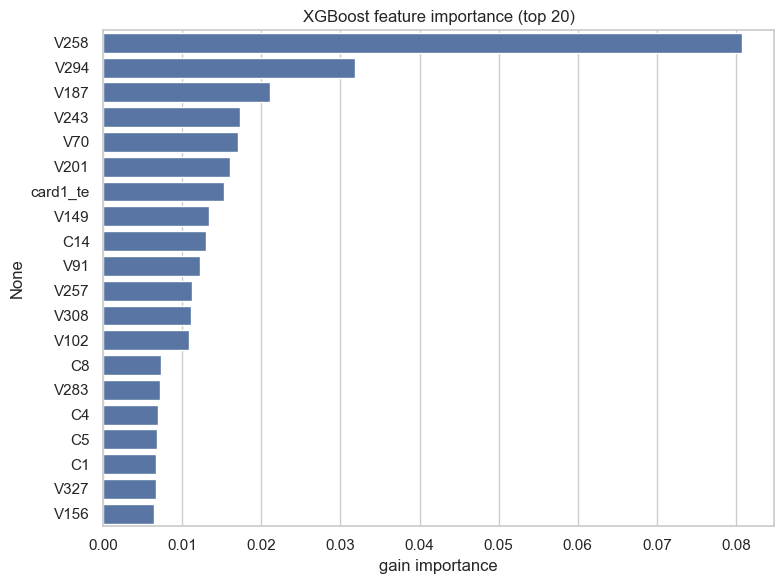

Null-importance noise ceiling: 0.0059
Top features comfortably above noise: 20 / 20
Top-30 importance overlap across time folds: 33% (below 60% threshold — check drift)
Spearman rank correlation of importances (early vs late train): 0.477
Family-clustered overlap of top-30 (V/C/D/M collapsed): 43%

Stage A candidate pool: 469 features (null-importance: 20/20 top features above noise).
Stability verdict: UNSTABLE across time folds — low set overlap, low rank correlation, and low family overlap. Treat high-importance features from a single split with caution.

=== Ablation: full feature set vs engineered-features-removed ===
Full set: 469  |  raw-only: 431  |  engineered removed: 38
Validation PR-AUC  full=0.5158  raw-only=0.5003  delta=+0.0154
OOT test PR-AUC    full=0.5209  raw-only=0.5072  delta=+0.0137
Verdict: engineered features add material incremental signal (even if they don't dominate the raw gain-importance chart — trees spread credit across correlated V-columns).

=== Stage B

In [24]:
# --- (1) Importance ranking from the trained XGBoost -------------------------
imp = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
top = imp.head(20)
plt.figure(figsize=(8, 6))
sns.barplot(x=top.values, y=top.index, color="#4C72B0")
plt.title("XGBoost feature importance (top 20)"); plt.xlabel("gain importance")
plt.tight_layout(); plt.show()

# --- (2) Null-importance sanity check (small model on a train subsample) ------
rng = np.random.RandomState(SEED)
sub = rng.choice(len(X_train), size=min(150_000, len(X_train)), replace=False)
Xs = X_train[FEATURES].iloc[sub]
small = dict(n_estimators=200, learning_rate=0.1, max_depth=6, subsample=0.8,
             colsample_bytree=0.8, tree_method="hist", random_state=SEED, n_jobs=-1)

real = xgb.XGBClassifier(**small).fit(Xs, y_train.iloc[sub])
real_imp = pd.Series(real.feature_importances_, index=FEATURES)
shuf = xgb.XGBClassifier(**small).fit(Xs, y_train.iloc[sub].sample(frac=1, random_state=SEED).values)
null_imp = pd.Series(shuf.feature_importances_, index=FEATURES)

noise = null_imp.max()
suspicious = real_imp[(real_imp > 0) & (real_imp <= noise) & (real_imp.index.isin(top.index))]
print(f"Null-importance noise ceiling: {noise:.4f}")
print(f"Top features comfortably above noise: {(top > noise).sum()} / {len(top)}")

# --- (3) Stability across two time folds (early vs late train) ---------------
half = len(X_train) // 2
m_early = xgb.XGBClassifier(**small).fit(X_train[FEATURES].iloc[:half], y_train.iloc[:half])
m_late  = xgb.XGBClassifier(**small).fit(X_train[FEATURES].iloc[half:], y_train.iloc[half:])
top_early = set(pd.Series(m_early.feature_importances_, index=FEATURES).nlargest(30).index)
top_late  = set(pd.Series(m_late.feature_importances_, index=FEATURES).nlargest(30).index)
overlap = len(top_early & top_late) / 30
stable_set = overlap >= 0.6
print(f"Top-30 importance overlap across time folds: {overlap:.0%} "
      f"({'stable' if stable_set else 'below 60% threshold — check drift'})")

# Rank correlation of the FULL importance vectors (not just the top-30 set)
imp_early = pd.Series(m_early.feature_importances_, index=FEATURES)
imp_late  = pd.Series(m_late.feature_importances_, index=FEATURES)
spearman = imp_early.corr(imp_late, method="spearman")
print(f"Spearman rank correlation of importances (early vs late train): {spearman:.3f}")

def feature_family(name):
    """Collapse near-duplicate anonymized blocks so correlated V-columns don't look like drift."""
    if len(name) >= 2 and name[0] in {"V", "C", "D", "M"} and name[1:].split("_")[0].isdigit():
        return name[0] + "_block"
    if name.startswith("id_"):
        return "id_block"
    if name.startswith("card") and name[4:5].isdigit():
        return "card_raw"
    return name  # engineered / distinctive features keep their identity

fam_early = {feature_family(f) for f in top_early}
fam_late  = {feature_family(f) for f in top_late}
fam_overlap = len(fam_early & fam_late) / max(len(fam_early | fam_late), 1)
print(f"Family-clustered overlap of top-30 (V/C/D/M collapsed): {fam_overlap:.0%}")

if stable_set:
    stability_verdict = "time-stable (top-30 set overlap ≥ 60%)"
elif spearman >= 0.6 or fam_overlap >= 0.6:
    stability_verdict = (
        "NOT set-stable at top-30 (overlap < 60%), but this looks like correlated "
        "anonymized columns trading rank rather than genuine temporal drift "
        f"(Spearman={spearman:.2f}, family overlap={fam_overlap:.0%})"
    )
else:
    stability_verdict = (
        "UNSTABLE across time folds — low set overlap, low rank correlation, and low "
        "family overlap. Treat high-importance features from a single split with caution."
    )
print(f"\nStage A candidate pool: {len(FEATURES)} features "
      f"(null-importance: {(top > noise).sum()}/{len(top)} top features above noise).")
print(f"Stability verdict: {stability_verdict}")

# --- (4) Ablation: do engineered features actually move PR-AUC? --------------
# Full model is already trained. Retrain the same XGBoost recipe on RAW Vesta
# columns only (no velocity / z-score / encodings / graph-lite / rule flags).
print("\n=== Ablation: full feature set vs engineered-features-removed ===")
print(f"Full set: {len(FEATURES)}  |  raw-only: {len(RAW_FEATURES)}  |  "
      f"engineered removed: {len(ENGINEERED_FEATURES)}")
try:
    xgb_raw = xgb.XGBClassifier(early_stopping_rounds=150, **xgb_params)
    xgb_raw.fit(X_train[RAW_FEATURES], y_train,
                eval_set=[(X_valid[RAW_FEATURES], y_valid)], verbose=False)
except TypeError:
    xgb_raw = xgb.XGBClassifier(**xgb_params)
    xgb_raw.fit(X_train[RAW_FEATURES], y_train,
                eval_set=[(X_valid[RAW_FEATURES], y_valid)],
                early_stopping_rounds=150, verbose=False)

ap_full_val = average_precision_score(y_valid, preds["XGBoost"]["valid"])
ap_raw_val  = average_precision_score(y_valid, xgb_raw.predict_proba(X_valid[RAW_FEATURES])[:, 1])
ap_full_test = average_precision_score(y_test, preds["XGBoost"]["test"])
ap_raw_test  = average_precision_score(y_test, xgb_raw.predict_proba(X_test[RAW_FEATURES])[:, 1])
d_val, d_test = ap_full_val - ap_raw_val, ap_full_test - ap_raw_test
print(f"Validation PR-AUC  full={ap_full_val:.4f}  raw-only={ap_raw_val:.4f}  delta={d_val:+.4f}")
print(f"OOT test PR-AUC    full={ap_full_test:.4f}  raw-only={ap_raw_test:.4f}  delta={d_test:+.4f}")
if d_test >= 0.01:
    print("Verdict: engineered features add material incremental signal "
          "(even if they don't dominate the raw gain-importance chart — trees spread credit "
          "across correlated V-columns).")
elif d_test > 0:
    print("Verdict: engineered features add a small positive delta. Honest takeaway: "
          "Vesta's pre-built V/C columns already carry most of the signal; velocity/graph-lite "
          "are supporting, not headline, drivers on this dataset.")
else:
    print("Verdict: removing engineered features did not hurt (or slightly helped) OOT PR-AUC. "
          "Do not claim velocity/graph-lite as a performance win on this dataset; keep them "
          "for interpretability/rules, not for lift.")
ENGINEERED_DELTA_TEST = d_test

# --- (5) Stage B: prune to a deployable GBM feature set ----------------------
# Industry pattern: wide candidate pool (Stage A) → compact owned set (Stage B).
# Core = named/engineered features (same as LogReg). Extra = correlation-pruned
# Vesta slice. Isolation Forest is NOT given this set — it stays on LR_FEATURES.
CORR_THRESHOLD = 0.90
MAX_GBM_FEATURES = 100          # target size for XGBoost / LightGBM
ACCEPT_DROP = 0.01              # max allowed valid PR-AUC drop vs 469-ceiling
MIN_IMPORTANCE = max(float(noise) * 0.25, 1e-8)

core = [c for c in LR_FEATURES if c in FEATURES]
vesta_candidates = [c for c in FEATURES if c not in core]
ranked = [c for c in imp.sort_values(ascending=False).index
          if c in vesta_candidates and float(imp[c]) > MIN_IMPORTANCE]

# Pairwise |corr| on a train subsample (full 400k × 400 is unnecessary for pruning)
corr_cols = ranked[: min(250, len(ranked))]
n_corr = min(80_000, len(X_train))
idx_corr = np.random.RandomState(SEED).choice(len(X_train), size=n_corr, replace=False)
corr_abs = (X_train.iloc[idx_corr][corr_cols].corr().abs()
            if corr_cols else pd.DataFrame())

kept_extra = []
n_dropped_corr = 0
for f in ranked:
    if len(core) + len(kept_extra) >= MAX_GBM_FEATURES:
        break
    if f in corr_abs.columns and kept_extra:
        peers = [k for k in kept_extra if k in corr_abs.columns]
        if peers:
            mx = corr_abs.loc[f, peers].replace([np.inf, -np.inf], np.nan).fillna(0).max()
            if float(mx) >= CORR_THRESHOLD:
                n_dropped_corr += 1
                continue
    kept_extra.append(f)

GBM_FEATURES = core + kept_extra
print("\n=== Stage B — GBM feature prune (what would actually be deployed) ===")
print(f"Core (named / engineered / rules, same as LogReg): {len(core)}")
print(f"Vesta slice after importance + |corr|>{CORR_THRESHOLD:.2f} prune: {len(kept_extra)}  "
      f"(dropped {n_dropped_corr} near-duplicates, "
      f"{len(vesta_candidates) - len(kept_extra)} unused Vesta candidates)")
print(f"GBM_FEATURES total: {len(GBM_FEATURES)}  (cap {MAX_GBM_FEATURES})")
print(f"LogReg stays on LR_FEATURES ({len(LR_FEATURES)}).")
print(f"Isolation Forest stays on IF_FEATURES ({len(IF_FEATURES)}; target encodings dropped).")

def _fit_xgb_on(cols):
    try:
        m = xgb.XGBClassifier(early_stopping_rounds=150, **xgb_params)
        m.fit(X_train[cols], y_train, eval_set=[(X_valid[cols], y_valid)], verbose=False)
    except TypeError:
        m = xgb.XGBClassifier(**xgb_params)
        m.fit(X_train[cols], y_train, eval_set=[(X_valid[cols], y_valid)],
              early_stopping_rounds=150, verbose=False)
    return m

# Freeze Stage A (full) as the ceiling, then retrain on the pruned set
preds["XGBoost_full"] = dict(preds["XGBoost"])
models["XGBoost_full"] = xgb_model
model_features["XGBoost_full"] = list(FEATURES)

print("\nRetraining XGBoost on GBM_FEATURES ...")
xgb_pruned = _fit_xgb_on(GBM_FEATURES)
preds["XGBoost_pruned"] = {
    "valid": xgb_pruned.predict_proba(X_valid[GBM_FEATURES])[:, 1],
    "test":  xgb_pruned.predict_proba(X_test[GBM_FEATURES])[:, 1],
}
model_features["XGBoost_pruned"] = GBM_FEATURES
models["XGBoost_pruned"] = xgb_pruned

ap_full_v = average_precision_score(y_valid, preds["XGBoost_full"]["valid"])
ap_pru_v  = average_precision_score(y_valid, preds["XGBoost_pruned"]["valid"])
ap_full_t = average_precision_score(y_test,  preds["XGBoost_full"]["test"])
ap_pru_t  = average_precision_score(y_test,  preds["XGBoost_pruned"]["test"])
drop_v, drop_t = ap_full_v - ap_pru_v, ap_full_t - ap_pru_t
print(f"XGBoost PR-AUC  valid  full={ap_full_v:.4f}  pruned={ap_pru_v:.4f}  drop={drop_v:+.4f}")
print(f"XGBoost PR-AUC  OOT    full={ap_full_t:.4f}  pruned={ap_pru_t:.4f}  drop={drop_t:+.4f}")

PRUNE_ACCEPTED = drop_v <= ACCEPT_DROP
if PRUNE_ACCEPTED:
    xgb_model = xgb_pruned
    models["XGBoost"] = xgb_pruned
    model_features["XGBoost"] = GBM_FEATURES
    preds["XGBoost"] = preds["XGBoost_pruned"]
    print(f"Prune ACCEPTED (valid drop {drop_v:+.4f} ≤ {ACCEPT_DROP}). "
          f"Deployed XGBoost uses {len(GBM_FEATURES)} features.")
else:
    GBM_FEATURES = list(FEATURES)  # scoring path stays on the ceiling
    print(f"Prune REJECTED (valid drop {drop_v:+.4f} > {ACCEPT_DROP}). "
          f"Deployed XGBoost stays on the full {len(FEATURES)}-feature ceiling. "
          "The pruned model is still reported in the comparison table.")

# LightGBM: same feature decision so the GBM vs GBM comparison stays fair
if HAS_LGBM:
    preds["LightGBM_full"] = dict(preds["LightGBM"])
    models["LightGBM_full"] = models["LightGBM"]
    model_features["LightGBM_full"] = list(FEATURES)
    if PRUNE_ACCEPTED:
        print("Retraining LightGBM on GBM_FEATURES ...")
        try:
            lgbm_pruned = lgb.LGBMClassifier(
                n_estimators=3000, learning_rate=0.03, num_leaves=64, max_depth=-1,
                min_child_samples=50, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                reg_lambda=1.0, scale_pos_weight=SCALE_POS_WEIGHT,
                objective="binary", metric="auc",
                random_state=SEED, n_jobs=-1, verbosity=-1,
            )
            try:
                _es = lgb.early_stopping(stopping_rounds=150, first_metric_only=True, verbose=False)
            except TypeError:
                _es = lgb.early_stopping(150, verbose=False)
            lgbm_pruned.fit(
                X_train[model_features["XGBoost"]], y_train,
                eval_set=[(X_valid[model_features["XGBoost"]], y_valid)],
                eval_metric="auc",
                callbacks=[_es, lgb.log_evaluation(0)],
            )
            _cols = model_features["XGBoost"]
            models["LightGBM"] = lgbm_pruned
            model_features["LightGBM"] = _cols
            preds["LightGBM"] = {
                "valid": lgbm_pruned.predict_proba(X_valid[_cols])[:, 1],
                "test":  lgbm_pruned.predict_proba(X_test[_cols])[:, 1],
            }
            print(f"LightGBM retrained on {len(_cols)} features "
                  f"(best_iteration_={getattr(lgbm_pruned, 'best_iteration_', None)}).")
        except Exception as e:
            print(f"[LightGBM prune retrain skipped] {type(e).__name__}: {e}")
            print("LightGBM stays on the Stage A full feature set.")
    else:
        print("LightGBM stays on the full feature set (XGBoost prune was rejected).")

print("\nFeature-set decision:")
print(f"  LogReg                   : {len(LR_FEATURES)}")
print(f"  Isolation Forest         : {len(IF_FEATURES)}  (named set, TE dropped)")
print(f"  XGBoost deployed         : {len(model_features['XGBoost'])}"
      f"  ({'pruned' if PRUNE_ACCEPTED else 'full ceiling'})")
if "LightGBM" in model_features:
    print(f"  LightGBM deployed        : {len(model_features['LightGBM'])}")


## Phase 8 — Evaluation & Champion Selection

**Concept.** Now we compare every model on the **untouched OOT test set** using the metrics that matter, pick a champion by an explicit rubric, quantify the uncertainty of that choice, and check for hidden weak segments.

### 8.1 Head-to-head comparison

**Method.** One table across Rules-only, LogReg, XGBoost, LightGBM, and Isolation Forest — PR-AUC, ROC-AUC, recall@1%FPR, Precision@K — plus overlaid precision-recall curves.

**Feature-set footnote (read this before comparing numbers):** Logistic Regression uses the **curated named set**. Isolation Forest uses that set **minus target encodings**. XGBoost and LightGBM use the **Stage B pruned set (~100)** when the prune is accepted, otherwise the full ~469 ceiling. `XGBoost_full` in the table is the Stage A ceiling (all candidates) so you can see what pruning cost. A large LogReg vs XGBoost gap is still **partly algorithm, partly feature-count**.

**Interview angle.** *"I compare all models on a single held-out OOT set with PR-AUC and operational metrics, including the rules-only baseline so the marginal value of ML is explicit."*


=== Model comparison on OOT test ===
                 PR_AUC  ROC_AUC  recall@1%FPR  prec@1000
model                                                    
LightGBM         0.5324   0.8915        0.4370     0.7860
XGBoost          0.5209   0.8844        0.4460     0.7780
XGBoost_pruned   0.4799   0.8693        0.3954     0.7260
LogReg           0.1603   0.7981        0.1197     0.2980
IsolationForest  0.0609   0.6781        0.0014     0.0080
Rules-only       0.0379   0.5087        0.0009     0.0250

Base rate (test): 3.747%  -> PR-AUC baseline for a random model.

Feature-set footnote:
  LogReg                   : 54 curated named features.
  Isolation Forest         : 51  (named set, TE dropped).
  XGBoost deployed         : 469  (Stage A full ceiling)
  LightGBM deployed        : 469
  XGBoost_full (ceiling)   : 469
  Do not read the LogReg vs XGBoost gap as a pure algorithm comparison.


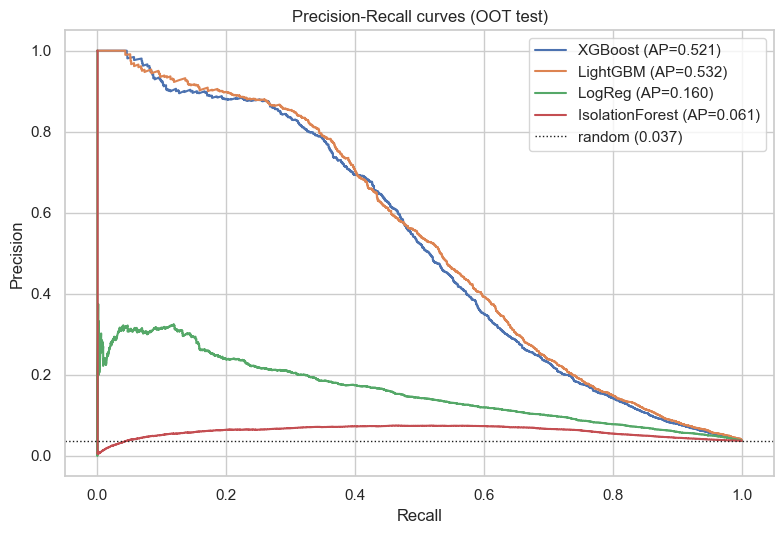

In [25]:
# --- Comparison table on the OOT test set ------------------------------------
# Deployed names first; Stage A ceiling rows included when they differ.
_model_order = [m for m in ["LogReg", "XGBoost", "LightGBM", "IsolationForest"] if m in preds]
rows = [evaluate("Rules-only", y_test, df.loc[test_mask, "rule_risk_count"].values)]
for name in _model_order:
    rows.append(evaluate(name, y_test, preds[name]["test"]))
if "XGBoost_full" in preds and len(model_features.get("XGBoost", [])) != len(model_features.get("XGBoost_full", [])):
    rows.append(evaluate("XGBoost_full", y_test, preds["XGBoost_full"]["test"]))
if (not PRUNE_ACCEPTED) and "XGBoost_pruned" in preds:
    rows.append(evaluate("XGBoost_pruned", y_test, preds["XGBoost_pruned"]["test"]))
if "LightGBM_full" in preds and "LightGBM" in model_features and \
        len(model_features.get("LightGBM", [])) != len(model_features.get("LightGBM_full", [])):
    rows.append(evaluate("LightGBM_full", y_test, preds["LightGBM_full"]["test"]))

results = (pd.DataFrame(rows).set_index("model")
           .sort_values("PR_AUC", ascending=False).round(4))
print("=== Model comparison on OOT test ===")
print(results)
print(f"\nBase rate (test): {y_test.mean():.3%}  -> PR-AUC baseline for a random model.")
print("\nFeature-set footnote:")
print(f"  LogReg                   : {len(LR_FEATURES)} curated named features.")
print(f"  Isolation Forest         : {len(model_features['IsolationForest'])}  (named set, TE dropped).")
print(f"  XGBoost deployed         : {len(model_features['XGBoost'])}  "
      f"({ 'Stage B pruned' if PRUNE_ACCEPTED else 'Stage A full ceiling' })")
if "LightGBM" in model_features:
    print(f"  LightGBM deployed        : {len(model_features['LightGBM'])}")
if "XGBoost_full" in model_features:
    print(f"  XGBoost_full (ceiling)   : {len(model_features['XGBoost_full'])}")
print("  Do not read the LogReg vs XGBoost gap as a pure algorithm comparison.")

# --- Precision-Recall curves -------------------------------------------------
plt.figure(figsize=(8, 5.5))
_curve = [m for m in ["XGBoost", "LightGBM", "LogReg", "IsolationForest"] if m in preds]
for name in _curve:
    pr, rc, _ = precision_recall_curve(y_test, preds[name]["test"])
    plt.plot(rc, pr, label=f"{name} (AP={average_precision_score(y_test, preds[name]['test']):.3f})")
if "XGBoost_full" in preds and PRUNE_ACCEPTED:
    pr, rc, _ = precision_recall_curve(y_test, preds["XGBoost_full"]["test"])
    plt.plot(rc, pr, ls="--", color="gray",
             label=f"XGBoost_full (AP={average_precision_score(y_test, preds['XGBoost_full']['test']):.3f})")
plt.axhline(y_test.mean(), color="k", ls=":", lw=1, label=f"random ({y_test.mean():.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall curves (OOT test)"); plt.legend(); plt.tight_layout(); plt.show()


### 8.2 Champion selection (rubric) + statistical rigor

**Concept.** Don't crown a champion on a single decimal place. Select on a **rubric** — predictive performance + business/operational fit + practical factors (speed, interpretability, stability) — and quantify whether the top-2 are even distinguishable using a **bootstrap confidence interval** on the PR-AUC gap.

**Method.** Pick the champion by **validation** PR-AUC among the supervised models (avoids peeking at test), then bootstrap the XGBoost-vs-LightGBM PR-AUC difference on test (~1000 resamples, 95% CI).

**Interview angle.** *"If the bootstrap CI for the PR-AUC gap crosses zero, I say the two models are statistically indistinguishable and pick on practical grounds — that's a more senior claim than 'model A beat model B by 0.003.'"*


In [26]:
# --- Champion by validation PR-AUC among supervised models -------------------
_supervised = [m for m in ["LogReg", "XGBoost", "LightGBM"] if m in preds]
val_ap = {m: average_precision_score(y_valid, preds[m]["valid"]) for m in _supervised}
CHAMPION = max(val_ap, key=val_ap.get)
print("Validation PR-AUC:", {k: round(v, 4) for k, v in val_ap.items()})
print(f"--> Champion (by validation PR-AUC): {CHAMPION}")
print("   Rubric also favors GBMs on interpretability-via-SHAP, NaN handling, and stability.")

# Deployed scorer follows the champion — do not hardcode a model name.
DEPLOYED = CHAMPION
DEPLOYED_FEATURES = model_features[DEPLOYED]
champ_test = preds[DEPLOYED]["test"]
print(f"--> Deployed scorer: {DEPLOYED}  ({len(DEPLOYED_FEATURES)} features)")

# --- Bootstrap 95% CI for PR-AUC(XGBoost) - PR-AUC(LightGBM) on test ---------
def bootstrap_ap_diff(y_true, p_a, p_b, n_boot=1000, seed=SEED):
    y_true = np.asarray(y_true); p_a = np.asarray(p_a); p_b = np.asarray(p_b)
    rng = np.random.RandomState(seed); N = len(y_true); diffs = []
    for _ in range(n_boot):
        idx = rng.randint(0, N, N)
        if y_true[idx].sum() == 0:      # need at least one positive
            continue
        diffs.append(average_precision_score(y_true[idx], p_a[idx])
                     - average_precision_score(y_true[idx], p_b[idx]))
    return np.percentile(diffs, [2.5, 50, 97.5])

# Compare XGBoost against the next-best available supervised model (LightGBM if present, else LogReg).
_rival = "LightGBM" if "LightGBM" in preds else "LogReg"
lo, mid, hi = bootstrap_ap_diff(y_test, preds["XGBoost"]["test"], preds[_rival]["test"])
verdict = ("indistinguishable (CI crosses 0)" if lo <= 0 <= hi
           else ("XGBoost better" if lo > 0 else f"{_rival} better"))
print(f"\nXGBoost - {_rival} PR-AUC diff (test): median={mid:+.4f}, 95% CI=[{lo:+.4f}, {hi:+.4f}]")
print(f"Verdict: {verdict}")


Validation PR-AUC: {'LogReg': 0.1427, 'XGBoost': 0.5158, 'LightGBM': 0.5153}
--> Champion (by validation PR-AUC): XGBoost
   Rubric also favors GBMs on interpretability-via-SHAP, NaN handling, and stability.
--> Deployed scorer: XGBoost  (469 features)

XGBoost - LightGBM PR-AUC diff (test): median=-0.0113, 95% CI=[-0.0177, -0.0060]
Verdict: LightGBM better


### 8.3 Segment-level performance

**Concept.** A strong overall PR-AUC can hide a weak spot — e.g. the model may be great on small purchases but poor on high-value ones (where losses are largest). Model-risk teams require this breakdown before sign-off.

**Method.** Report PR-AUC per segment for the deployed model: by **amount bucket** and by **identity present vs missing**.

**Interview angle.** *"I break performance down by amount and by identity availability — a model that's weak exactly where money is largest is a real finding, not a footnote."*


In [27]:
test_df = df.loc[test_mask].copy()
test_df["_score"] = champ_test
test_df["_identity"] = np.where(test_df["DeviceType"] >= 0, "identity_present", "identity_missing")
bucket_names = {0: "0-25", 1: "25-100", 2: "100-250", 3: "250-1000", 4: "1000+"}
test_df["_amt_seg"] = test_df["amt_bucket"].map(bucket_names)

def seg_report(frame, seg_col):
    out = []
    for seg, sub in frame.groupby(seg_col):
        if sub[TARGET].nunique() < 2:      # need both classes to score
            continue
        out.append({seg_col: seg, "n": len(sub), "fraud_rate": sub[TARGET].mean(),
                    "PR_AUC": average_precision_score(sub[TARGET], sub["_score"])})
    return pd.DataFrame(out).round(4)

print(f"=== Segment performance for deployed model ({DEPLOYED}) ===\n")
print("By transaction amount:")
print(seg_report(test_df, "_amt_seg").sort_values("_amt_seg"))
print("\nBy identity availability:")
print(seg_report(test_df, "_identity"))


=== Segment performance for deployed model (XGBoost) ===

By transaction amount:
   _amt_seg      n  fraud_rate  PR_AUC
0      0-25   4961      0.0865  0.6559
1   100-250  16643      0.0293  0.4354
2     1000+    879      0.0375  0.1525
3    25-100  31376      0.0306  0.5221
4  250-1000   5195      0.0581  0.5068

By identity availability:
          _identity      n  fraud_rate  PR_AUC
0  identity_missing  45982      0.0206  0.2048
1  identity_present  13072      0.0970  0.7222


## Phase 9 — Probability Calibration

**Concept.** Gradient-boosted scores rank well but aren't true probabilities — a raw "0.7" doesn't mean "70% chance of fraud." Since every downstream decision (risk score, cost-based thresholds) treats the number as a probability, we must **calibrate** it first.

**Method.** Fit **isotonic regression** (primary) on the held-out **calibration split** — never on train or test — mapping raw scores → honest probabilities. Compare against **Platt scaling** and measure the **Brier score** (lower = better) before/after, plus a **reliability diagram**. Also print **PR-AUC before vs after** calibration: isotonic is monotonic, so rank-order metrics should barely move. A large drop is a warning that the calibration split is too thin in the tail (or that isotonic fitted noise).

Logistic Regression is already a probability model — if it is the deployed champion we skip this step.

**Interview angle.** *"I calibrate on a dedicated split with isotonic regression and prove it with a reliability curve and Brier score — so when the system says 0.7, it really means roughly 70%."*


Calibration split: n=59,053  fraud cases=2,061  (3.49%) — isotonic needs a reasonably populated tail.
Brier score (lower is better): {'raw': 0.03357, 'isotonic': 0.02432, 'platt': 0.02479}
Selected calibrator: isotonic

PR-AUC  raw=0.5209  calibrated=0.5038  delta=-0.0171
Spearman(raw, calibrated) = 0.9868  (1.0 = ranks unchanged)
NOTE: PR-AUC moved more than tie-breaking usually explains. Possible causes: isotonic flattening sparse high-score bins, or many tied calibrated values. Inspect the reliability diagram; consider Platt if ranks look noisier.


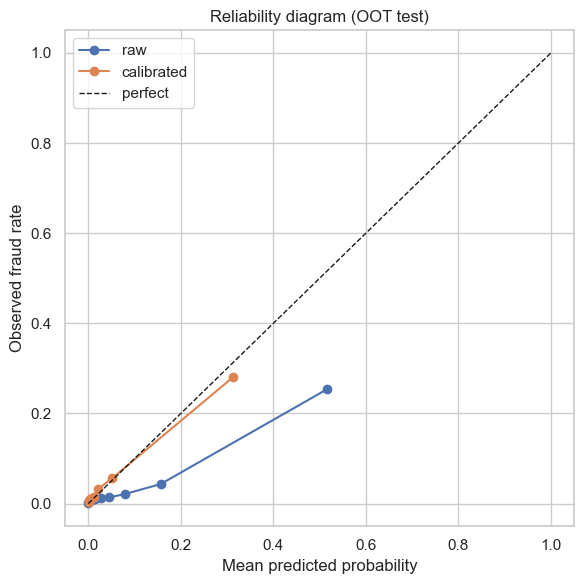

In [28]:
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression as PlattLR
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

print(f"Calibration split: n={len(y_calib):,}  fraud cases={int(y_calib.sum()):,}  "
      f"({y_calib.mean():.2%}) — isotonic needs a reasonably populated tail.")

# Raw deployed-model scores on calibration and test splits
raw_calib = models[DEPLOYED].predict_proba(X_calib[DEPLOYED_FEATURES])[:, 1]
raw_test = np.asarray(champ_test, dtype=float)

if DEPLOYED == "LogReg":
    print("LogReg is a probability model — skipping extra calibration.")
    CALIBRATOR, cal_name = None, "none (native LR)"
    test_cal = raw_test
    brier = {"raw": brier_score_loss(y_test, raw_test)}
    print("Brier score:", {k: round(v, 5) for k, v in brier.items()})
else:
    iso_cal = IsotonicRegression(out_of_bounds="clip").fit(raw_calib, y_calib)
    test_iso = iso_cal.predict(raw_test)
    platt = PlattLR(max_iter=1000).fit(raw_calib.reshape(-1, 1), y_calib)
    test_platt = platt.predict_proba(raw_test.reshape(-1, 1))[:, 1]
    brier = {
        "raw":      brier_score_loss(y_test, raw_test),
        "isotonic": brier_score_loss(y_test, test_iso),
        "platt":    brier_score_loss(y_test, test_platt),
    }
    print("Brier score (lower is better):", {k: round(v, 5) for k, v in brier.items()})
    CALIBRATOR = iso_cal if brier["isotonic"] <= brier["platt"] else platt
    cal_name = "isotonic" if CALIBRATOR is iso_cal else "platt"
    test_cal = test_iso if CALIBRATOR is iso_cal else test_platt
    print(f"Selected calibrator: {cal_name}")

# Rank-order check: PR-AUC should barely move under a monotonic calibrator
ap_raw = average_precision_score(y_test, raw_test)
ap_cal = average_precision_score(y_test, test_cal)
spear_rank = pd.Series(raw_test).corr(pd.Series(test_cal), method="spearman")
print(f"\nPR-AUC  raw={ap_raw:.4f}  calibrated={ap_cal:.4f}  delta={ap_cal-ap_raw:+.4f}")
print(f"Spearman(raw, calibrated) = {spear_rank:.4f}  (1.0 = ranks unchanged)")
if abs(ap_cal - ap_raw) > 0.01:
    print("NOTE: PR-AUC moved more than tie-breaking usually explains. Possible causes: "
          "isotonic flattening sparse high-score bins, or many tied calibrated values. "
          "Inspect the reliability diagram; consider Platt if ranks look noisier.")
else:
    print("PR-AUC movement is small — calibration is behaving like a monotonic map.")

# --- Reliability diagram -----------------------------------------------------
plt.figure(figsize=(6, 6))
for label, p in [("raw", raw_test)] + ([] if str(cal_name).startswith("none") else [("calibrated", test_cal)]):
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=label)
plt.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed fraud rate")
plt.title("Reliability diagram (OOT test)"); plt.legend(); plt.tight_layout(); plt.show()


## Phase 10 — Explainability & Reason Codes (SHAP)

**Concept.** A fraud decision must be explainable — to analysts, to customers ("why was I declined?"), and to regulators. **SHAP** attributes each prediction to its features, both **globally** (what drives fraud overall) and **locally** (why *this* transaction scored high).

**Method.** `shap.TreeExplainer` on the deployed tree model (XGBoost or LightGBM). We show a global importance summary, then map each transaction's top positive SHAP contributors to human-readable **reason codes**. Anonymized Vesta columns (V/C/D/M) dominate gain importance on this dataset, so the mapping covers those families explicitly (`VESTA_RISK_SIGNAL`, `HIGH_ACTIVITY_COUNTS`, `UNUSUAL_TIME_DELTA`, `IDENTITY_MISMATCH`) instead of collapsing everything to a generic `MODEL_RISK` bucket. Rule-engine flags that fired are prepended so a velocity breach still shows as `HIGH_VELOCITY`.

**Interview angle.** *"SHAP gives me global drivers and per-transaction explanations, and I translate them into standardized reason codes — mirroring adverse-action requirements in real lending/fraud systems (SR 11-7-style)."*


shap 0.52.0


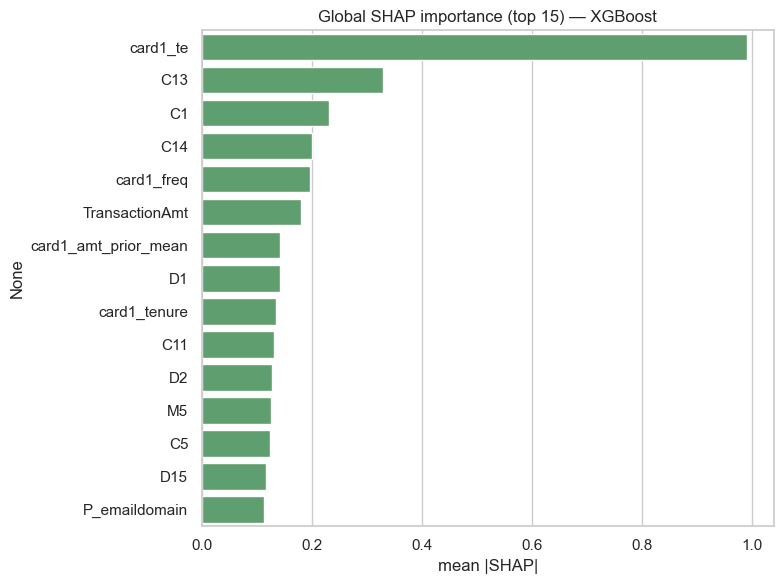


Local explanation for a high-risk fraud transaction (XGBoost):
C1         2.2721
id_04      1.4457
V258       1.4079
card1_te   1.0304
C11        0.6912
V45        0.5516
dtype: float32
Reason codes: ['HIGH_ACTIVITY_COUNTS', 'DEVICE_RISK', 'VESTA_RISK_SIGNAL']


In [29]:
# Map a raw feature name to a business reason code
def feature_to_reason(feat):
    """Map a feature name to a business-readable reason code.

    Anonymized Vesta columns (V/C/D/M/id) dominate importance on IEEE-CIS, so they
    get family-level codes rather than a generic MODEL_RISK dump. Engineered
    behavioural features keep the more specific codes from the spec.
    """
    f = feat.lower()
    # Rule flags already carry the reason-code name
    if feat.startswith("rule_"):
        return feat[len("rule_"):]
    # Engineered / named fields first (more specific)
    if any(t in f for t in ["cnt_", "velocity", "time_since", "rapid"]):
        return "HIGH_VELOCITY"
    if any(t in f for t in ["amt_zscore", "amt_to_prior", "amt_cents", "amt_log",
                            "amt_bucket", "transactionamt", "unusual_amount"]):
        return "UNUSUAL_AMOUNT"
    if any(t in f for t in ["prior_cnt", "tenure", "new_entity"]):
        return "NEW_ENTITY"
    if "email" in f:
        return "HIGH_RISK_EMAIL"
    if any(t in f for t in ["addr", "region", "dist", "diversity"]):
        return "UNUSUAL_LOCATION"
    if f.startswith("card") or "_te" in f or "_freq" in f:
        return "CARD_RISK"
    if any(t in f for t in ["device", "id_"]):
        return "DEVICE_RISK"
    # Anonymized Vesta families — name the family, don't hide them as MODEL_RISK
    if len(feat) >= 2 and feat[0] == "V" and feat[1:].split("_")[0].isdigit():
        return "VESTA_RISK_SIGNAL"       # Vesta aggregate/behavioural features
    if len(feat) >= 2 and feat[0] == "C" and feat[1:].split("_")[0].isdigit():
        return "HIGH_ACTIVITY_COUNTS"    # counting features (addr/card associations)
    if len(feat) >= 2 and feat[0] == "D" and feat[1:].split("_")[0].isdigit():
        return "UNUSUAL_TIME_DELTA"      # timedelta vs prior activity
    if len(feat) >= 2 and feat[0] == "M" and feat[1:].split("_")[0].isdigit():
        return "IDENTITY_MISMATCH"       # match flags (name/address/card)
    if feat in {"ProductCD"} or f.startswith("product"):
        return "PRODUCT_RISK"
    return "MODEL_RISK"

def reason_codes_from_contribs(contribs, feature_names, top=3):
    order = np.argsort(contribs)[::-1]
    codes = []
    for i in order:
        if contribs[i] <= 0:
            break
        code = feature_to_reason(feature_names[i])
        if code not in codes:
            codes.append(code)
        if len(codes) >= top:
            break
    return codes or ["MODEL_RISK"]

try:
    if DEPLOYED not in ("XGBoost", "LightGBM"):
        raise RuntimeError(f"TreeExplainer is for tree models; deployed={DEPLOYED}")
    import shap
    print("shap", shap.__version__)
    sample_idx = np.random.RandomState(SEED).choice(len(X_test), size=min(2000, len(X_test)), replace=False)
    X_shap = X_test[DEPLOYED_FEATURES].iloc[sample_idx]
    tree_model = models[DEPLOYED]
    explainer = shap.TreeExplainer(tree_model)
    sv = explainer.shap_values(X_shap)
    sv = sv[1] if isinstance(sv, list) else sv     # handle list output on some versions

    # Global importance (mean |SHAP|)
    global_imp = pd.Series(np.abs(sv).mean(0), index=DEPLOYED_FEATURES).sort_values(ascending=False)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=global_imp.head(15).values, y=global_imp.head(15).index, color="#55A868")
    plt.title(f"Global SHAP importance (top 15) — {DEPLOYED}"); plt.xlabel("mean |SHAP|")
    plt.tight_layout(); plt.show()

    # Local example: a fraud the model scored high
    local_pos = np.where(y_test.values[sample_idx] == 1)[0]
    j = local_pos[np.argmax(preds[DEPLOYED]["test"][sample_idx][local_pos])] if len(local_pos) else 0
    contribs = sv[j]
    top_local = pd.Series(contribs, index=DEPLOYED_FEATURES).sort_values(ascending=False).head(6)
    print(f"\nLocal explanation for a high-risk fraud transaction ({DEPLOYED}):")
    print(top_local.round(4))
    print("Reason codes:", reason_codes_from_contribs(contribs, DEPLOYED_FEATURES))
    SHAP_OK = True
except Exception as e:
    print(f"[SHAP skipped] {type(e).__name__}: {e}  ->  pip install shap")
    print("Reason codes will use rule flags + native tree pred_contribs at scoring time.")
    explainer = None
    SHAP_OK = False


## Phase 11 — Risk Score (0–1000)

**Concept.** Fraud-ops analysts and card-network teams work with a **risk score**, not a probability — the same idea as a credit bureau score. We convert the calibrated probability into a 0–1000 scale.

**Method.** `risk_score = round(calibrated_probability * 1000)`. It's a presentation layer (rank-preserving), not an accuracy change — but it's the number that actually appears on an analyst's screen.

**Interview angle.** *"The risk score is a business-facing rescaling of a calibrated probability — cosmetically like a bureau score — so ops teams get a familiar 0–1000 number to set policy on."*


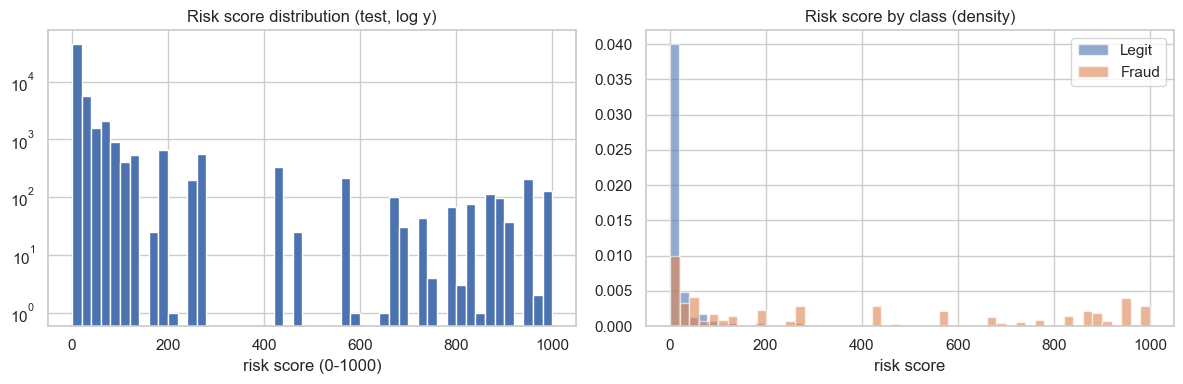

Median risk | legit: 4.0, fraud: 259.0


In [30]:
def to_risk_score(prob):
    return np.clip(np.round(np.asarray(prob) * 1000), 0, 1000).astype(int)

risk_test = to_risk_score(test_cal)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(risk_test, bins=50, color="#4C72B0")
ax[0].set_yscale("log"); ax[0].set_title("Risk score distribution (test, log y)")
ax[0].set_xlabel("risk score (0-1000)")
for label, sub in pd.DataFrame({"risk": risk_test, "y": y_test.values}).groupby("y"):
    ax[1].hist(sub["risk"], bins=50, alpha=0.6, density=True,
               label="Fraud" if label == 1 else "Legit")
ax[1].set_title("Risk score by class (density)"); ax[1].set_xlabel("risk score"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"Median risk | legit: {np.median(risk_test[y_test.values==0])}, "
      f"fraud: {np.median(risk_test[y_test.values==1])}")


## Phase 12 — Decision Engine & Cost-Based Thresholds

**Concept.** A probability isn't a decision. We map the calibrated probability to **APPROVE / CHALLENGE / DECLINE** using two thresholds, and we **derive** those thresholds by minimizing **expected business cost** — not by eyeballing round numbers.

**Cost model (three actions, from `CONFIG['costs']`):**
- **Approve** a fraud → lose the amount; approve legit → 0.
- **Decline** legit → friction cost; decline fraud → prevented (0).
- **Challenge** → a step-up cost, plus: legit sometimes abandons (lost revenue), fraud sometimes still passes (residual loss).

We sweep `(threshold_low, threshold_high)` on the **validation** set, subject to a **review-capacity budget** (max challenge rate), and pick the minimum-cost pair. Then we apply it once to the OOT test.

**Interview angle.** *"My thresholds come from an expected-cost curve under an explicit 3-action cost model, constrained by review capacity — so I can say 'we derived 0.9', not 'we guessed 0.9.'"*


Derived thresholds -> APPROVE < 0.06 | CHALLENGE | DECLINE >= 0.2
Validation expected cost: $111,503  |  challenge rate: 4.49% (budget 5%)


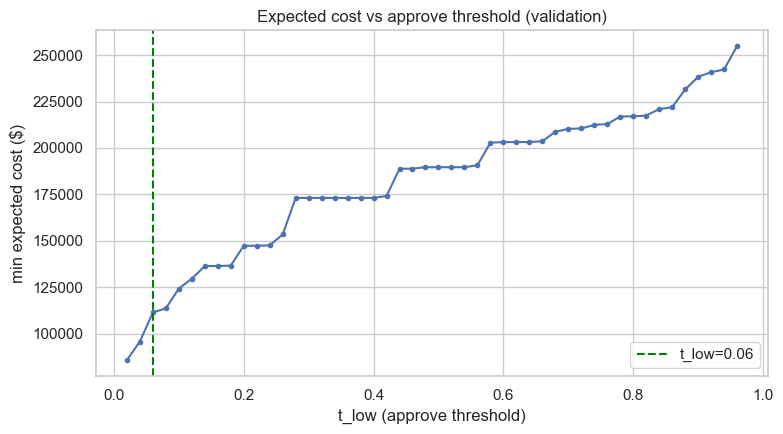

In [31]:
C = CONFIG["costs"]

def expected_cost(prob, y_true, amount, t_low, t_high):
    """Total expected business cost for approve/challenge/decline at these thresholds."""
    prob = np.asarray(prob); y = np.asarray(y_true); amt = np.asarray(amount, dtype=float)
    approve = prob < t_low
    decline = prob >= t_high
    challenge = ~approve & ~decline

    cost = np.zeros(len(prob))
    # Approve: fraud costs the amount; legit free
    cost[approve & (y == 1)] += amt[approve & (y == 1)]
    # Decline: legit costs friction; fraud prevented (0)
    cost[decline & (y == 0)] += C["fp_friction"]
    # Challenge: base cost for everyone challenged
    cost[challenge] += C["challenge_cost"]
    #   legit challenged: some abandon -> lost revenue
    cost[challenge & (y == 0)] += (1 - C["p_legit_pass"]) * C["p_legit_abandon_loss"]
    #   fraud challenged: some pass -> residual loss (amount)
    fc = challenge & (y == 1)
    cost[fc] += C["p_fraud_pass"] * amt[fc]
    return cost.sum(), challenge.mean()

# Sweep thresholds on VALIDATION, respect the review-capacity budget
amt_valid = df.loc[df["_split"] == "valid", "TransactionAmt"].values
_raw_valid = np.asarray(preds[DEPLOYED]["valid"], dtype=float)
if CALIBRATOR is None:
    prob_valid_cal = _raw_valid
elif cal_name == "isotonic":
    prob_valid_cal = CALIBRATOR.predict(_raw_valid)
else:
    prob_valid_cal = CALIBRATOR.predict_proba(_raw_valid.reshape(-1, 1))[:, 1]

grid = np.round(np.arange(0.02, 0.99, 0.02), 3)
best = {"cost": np.inf}
cost_curve = []
for tl in grid:
    for th in grid[grid > tl]:
        total, ch_rate = expected_cost(prob_valid_cal, y_valid, amt_valid, tl, th)
        if ch_rate <= CONFIG["review_capacity_rate"] and total < best["cost"]:
            best = {"cost": total, "t_low": tl, "t_high": th, "ch_rate": ch_rate}
    # for the curve, record best t_high given tl
    row = [expected_cost(prob_valid_cal, y_valid, amt_valid, tl, th)[0] for th in grid[grid > tl]]
    if row:
        cost_curve.append((tl, min(row)))

T_LOW, T_HIGH = best["t_low"], best["t_high"]
print(f"Derived thresholds -> APPROVE < {T_LOW} | CHALLENGE | DECLINE >= {T_HIGH}")
print(f"Validation expected cost: ${best['cost']:,.0f}  |  challenge rate: {best['ch_rate']:.2%} "
      f"(budget {CONFIG['review_capacity_rate']:.0%})")

xs, ys = zip(*cost_curve)
plt.figure(figsize=(8, 4.5))
plt.plot(xs, ys, marker="o", ms=3)
plt.axvline(T_LOW, color="green", ls="--", label=f"t_low={T_LOW}")
plt.xlabel("t_low (approve threshold)"); plt.ylabel("min expected cost ($)")
plt.title("Expected cost vs approve threshold (validation)"); plt.legend()
plt.tight_layout(); plt.show()


In [33]:
# --- Apply the decision policy to the OOT test -------------------------------
amt_test = df.loc[test_mask, "TransactionAmt"].values

def make_decision(prob):
    if prob >= T_HIGH:  return "DECLINE"
    if prob <  T_LOW:   return "APPROVE"
    return "CHALLENGE"

decisions = np.array([make_decision(p) for p in test_cal])
dist = pd.Series(decisions).value_counts(normalize=True).reindex(
    ["APPROVE", "CHALLENGE", "DECLINE"]).fillna(0)
print("Decision distribution (OOT test):")
for k, v in dist.items():
    print(f"  {k:<10} {v:6.2%}")

# --- Business value vs baselines --------------------------------------------
approve_all_cost = amt_test[y_test.values == 1].sum()                 # approve everything
model_cost, ch_rate = expected_cost(test_cal, y_test, amt_test, T_LOW, T_HIGH)
rules_pred = (df.loc[test_mask, "rule_risk_count"].values > 0)
rules_cost = (amt_test[(~rules_pred) & (y_test.values == 1)].sum()    # missed fraud
              + C["fp_friction"] * ((rules_pred) & (y_test.values == 0)).sum())  # blocked legit

print(f"\nExpected cost on OOT test:")
print(f"  Approve-all baseline : ${approve_all_cost:,.0f}")
print(f"  Rules-only baseline  : ${rules_cost:,.0f}")
print(f"  Full system (ours)   : ${model_cost:,.0f}")
print(f"  Savings vs approve-all: ${approve_all_cost - model_cost:,.0f} "
      f"({100*(approve_all_cost - model_cost)/max(approve_all_cost,1):.1f}%)")
print(f"  Savings vs rules-only : ${rules_cost - model_cost:,.0f}")


Decision distribution (OOT test):
  APPROVE    91.29%
  CHALLENGE   4.91%
  DECLINE     3.79%

Expected cost on OOT test:
  Approve-all baseline : $341,453
  Rules-only baseline  : $279,515
  Full system (ours)   : $147,759
  Savings vs approve-all: $193,694 (56.7%)
  Savings vs rules-only : $131,756


### 12.1 Structured output, hard overrides & the persisted artifact

**Concept.** The deliverable of a fraud system isn't a label — it's a **contract**: one JSON per transaction with probability, risk score, decision, and reason codes. We also add a **rule hard-override** layer (defense in depth: certain rule combinations force a decision regardless of the ML score) and **serialize the whole pipeline** so it can score without retraining.

**Method.** A `score_transaction()` function that consumes a featurized row and returns the JSON contract, plus `joblib.dump` of {model, calibrator, thresholds, features, rule params}.

> **Feature-store caveat:** in production the historical/velocity features come from a **precomputed feature store**; here we score already-featurized rows. So the latency we measure next reflects *decision logic*, not full feature recomputation.

**Interview angle.** *"The decision engine returns a typed JSON contract with reason codes and a rule-override field, and the whole scorer is a single serialized artifact — that's the function signature you'd actually deploy."*


In [34]:
import joblib

def _calibrate(raw):
    raw = np.atleast_1d(np.asarray(raw, dtype=float))
    if CALIBRATOR is None:
        return raw
    if cal_name == "isotonic":
        return CALIBRATOR.predict(raw)
    return CALIBRATOR.predict_proba(raw.reshape(-1, 1))[:, 1]

def _hard_override(feat_row):
    # Defense-in-depth: velocity abuse burst -> force DECLINE regardless of ML score
    if feat_row.get("rule_HIGH_VELOCITY", 0) == 1 and feat_row.get("rule_RAPID_REPEAT", 0) == 1:
        return "DECLINE", "VELOCITY_ABUSE"
    return None, None

def _pred_contribs(x_df):
    """Per-row additive contributions (SHAP-style) from the deployed tree model.
    Last column is bias and is dropped. Returns None if the model has no native contrib API.
    """
    try:
        if DEPLOYED == "XGBoost":
            booster = models["XGBoost"].get_booster()
            dmat = xgb.DMatrix(x_df[DEPLOYED_FEATURES], feature_names=list(DEPLOYED_FEATURES))
            contrib = booster.predict(dmat, pred_contribs=True)
            return np.asarray(contrib)[:, :-1]
        if DEPLOYED == "LightGBM":
            contrib = models["LightGBM"].predict(x_df[DEPLOYED_FEATURES], pred_contrib=True)
            return np.asarray(contrib)[:, :-1]
    except Exception:
        return None
    return None

def reason_codes_for_row(feat_row, contribs=None, top=3):
    """Rules that fired first, then SHAP/tree-contribution codes. Deduped, max `top`."""
    codes = []
    for rc in REASON_CODES:
        if feat_row.get(f"rule_{rc}", 0) == 1 and rc not in codes:
            codes.append(rc)
    if contribs is not None:
        for code in reason_codes_from_contribs(np.asarray(contribs).ravel(), DEPLOYED_FEATURES, top=top):
            if code not in codes:
                codes.append(code)
    return codes[:top] or ["MODEL_RISK"]

def score_transaction(feat_row):
    """feat_row: dict/Series with the deployed features. Returns the decision JSON contract."""
    x = pd.DataFrame([{f: feat_row.get(f, np.nan) for f in DEPLOYED_FEATURES}])
    raw = float(models[DEPLOYED].predict_proba(x)[:, 1][0])
    prob = float(np.clip(_calibrate(np.array([raw]))[0], 0, 1))
    contribs = _pred_contribs(x)
    codes = reason_codes_for_row(feat_row, contribs=None if contribs is None else contribs[0])
    forced, override = _hard_override(feat_row)
    decision = forced if forced else make_decision(prob)
    return {
        "fraud_probability": round(prob, 4),
        "risk_score": int(to_risk_score(prob)),
        "decision": decision,
        "reason_codes": codes,
        "rule_override": override,
    }

# --- Example on a real high-risk test transaction ---------------------------
ex_pos = np.where(y_test.values == 1)[0]
ex_i = ex_pos[np.argmax(test_cal[ex_pos])] if len(ex_pos) else 0
example_row = X_test[DEPLOYED_FEATURES].iloc[ex_i].to_dict()
print("Example decision JSON:")
print(json.dumps(score_transaction(example_row), indent=2))

# --- Persist the full scoring artifact --------------------------------------
artifact = {
    "model": models[DEPLOYED], "calibrator": CALIBRATOR, "cal_name": cal_name,
    "deployed": DEPLOYED, "features": DEPLOYED_FEATURES,
    "t_low": T_LOW, "t_high": T_HIGH,
    "reason_codes": REASON_CODES, "rule_params": RULE_PARAMS, "seed": SEED,
}
art_path = CONFIG["artifacts_dir"] / "fraud_scoring_pipeline.joblib"
joblib.dump(artifact, art_path)
print(f"\nSaved scoring artifact -> {art_path.resolve()}")


Example decision JSON:
{
  "fraud_probability": 1.0,
  "risk_score": 1000,
  "decision": "DECLINE",
  "reason_codes": [
    "NEW_ENTITY",
    "VESTA_RISK_SIGNAL",
    "HIGH_ACTIVITY_COUNTS"
  ],
  "rule_override": null
}

Saved scoring artifact -> E:\Fraud Detection Modeling Project\artifacts\fraud_scoring_pipeline.joblib


### 12.2 Simulated real-time scoring (latency)

**Concept.** We can't stand up Kafka in a notebook, but we can prove the pipeline works transaction-by-transaction and measure per-transaction latency.

**Method.** Iterate over a sample of test transactions in time order, score each one through `score_transaction()`, and report the median / p99 latency.

**Interview angle.** *"I simulate streaming by scoring transactions one at a time in time order and report p50/p99 latency — demonstrating the decision path runs end-to-end per event (features assumed served from a store in production)."*


In [35]:
import time

N_STREAM = 300  # keep small; per-row python scoring is intentionally naive
stream_rows = X_test[DEPLOYED_FEATURES].iloc[:N_STREAM].to_dict(orient="records")

latencies, outputs = [], []
for row in stream_rows:
    t0 = time.perf_counter()
    out = score_transaction(row)
    latencies.append((time.perf_counter() - t0) * 1000)  # ms
    outputs.append(out)

latencies = np.array(latencies)
print(f"Scored {N_STREAM} transactions one-by-one.")
print(f"Latency per transaction: median={np.median(latencies):.1f} ms | "
      f"p99={np.percentile(latencies, 99):.1f} ms")
print("\nSample decisions:")
for o in outputs[:3]:
    print(" ", json.dumps(o))
print("\n(Note: single-row python calls carry framework overhead; a vectorized/"
      "feature-store deployment would be far faster — this proves the logic, not the SLA.)")


Scored 300 transactions one-by-one.
Latency per transaction: median=69.0 ms | p99=158.7 ms

Sample decisions:
  {"fraud_probability": 0.0018, "risk_score": 2, "decision": "APPROVE", "reason_codes": ["IDENTITY_MISMATCH", "UNUSUAL_LOCATION", "HIGH_ACTIVITY_COUNTS"], "rule_override": null}
  {"fraud_probability": 0.0013, "risk_score": 1, "decision": "APPROVE", "reason_codes": ["IDENTITY_MISMATCH", "UNUSUAL_AMOUNT", "HIGH_ACTIVITY_COUNTS"], "rule_override": null}
  {"fraud_probability": 0.0039, "risk_score": 4, "decision": "APPROVE", "reason_codes": ["IDENTITY_MISMATCH", "CARD_RISK", "HIGH_ACTIVITY_COUNTS"], "rule_override": null}

(Note: single-row python calls carry framework overhead; a vectorized/feature-store deployment would be far faster — this proves the logic, not the SLA.)


## Phase 13 — Error Analysis

**Concept.** Metrics tell you *how often* you're wrong; error analysis tells you *why*. We inspect the model's mistakes at the chosen operating point and look for patterns we could fix with a new feature or rule.

**Method.** Split test errors into **false negatives** (missed fraud) and **false positives** (blocked legit), then profile them (amount, velocity, new-card, identity) against the population and surface concrete failure patterns.

**Interview angle.** *"I profiled my false negatives and false positives — e.g. misses cluster on low-amount new-card fraud — and turned each pattern into a concrete next step. That's what shows I understand where the model breaks."*


In [39]:
fa = df.loc[test_mask, ["TransactionID", "TransactionAmt",
                        f"{ENTITY}_cnt_1h", f"{ENTITY}_prior_cnt", "DeviceType"]].copy()
fa["prob"] = test_cal
fa["risk"] = risk_test
fa["y"] = y_test.values
fa["identity"] = fa["DeviceType"] >= 0

# Operating point: DECLINE threshold defines "flagged"
fn = fa[(fa.y == 1) & (fa.prob < T_HIGH)]   # missed fraud
fp = fa[(fa.y == 0) & (fa.prob >= T_HIGH)]  # blocked legit
tp = fa[(fa.y == 1) & (fa.prob >= T_HIGH)]

print(f"At DECLINE threshold {T_HIGH}:  caught fraud={len(tp):,}  "
      f"missed fraud (FN)={len(fn):,}  blocked legit (FP)={len(fp):,}")

def prof(name, g):
    return {"group": name, "n": len(g),
            "mean_amt": g.TransactionAmt.mean(),
            "median_amt": g.TransactionAmt.median(),
            "mean_vel_1h": g[f"{ENTITY}_cnt_1h"].mean(),
            "pct_new_card": (g[f"{ENTITY}_prior_cnt"] == 0).mean(),
            "pct_identity": g.identity.mean()}

print("\nProfiles:")
print(pd.DataFrame([prof("ALL", fa), prof("Missed fraud (FN)", fn),
                    prof("Blocked legit (FP)", fp)]).round(3).set_index("group"))

print("\nConcrete failure patterns (auto-derived):")
if len(fn):
    print(f"  1. {100*(fn.TransactionAmt < 100).mean():.0f}% of missed fraud is under $100 "
          f"(low-amount fraud is under-weighted).")
    print(f"  2. {100*(fn[f'{ENTITY}_prior_cnt'] == 0).mean():.0f}% of missed fraud is on new cards "
          f"(cold-start: little history to flag on).")
if len(fp):
    print(f"  3. {100*(fp[f'{ENTITY}_cnt_1h'] >= 3).mean():.0f}% of blocked-legit cases are high-velocity "
          f"(legit bursts look like fraud -> refine velocity features).")
print("\nExample missed-fraud transactions:")
print(fn.sort_values("TransactionAmt", ascending=False)
      .head(5)[["TransactionID", "TransactionAmt", "risk", f"{ENTITY}_prior_cnt"]].to_string(index=False))


At DECLINE threshold 0.2:  caught fraud=1,131  missed fraud (FN)=1,082  blocked legit (FP)=1,108

Profiles:
                        n  mean_amt  median_amt  mean_vel_1h  pct_new_card  \
group                                                                        
ALL                 59054  136.6570     68.5000       2.6480        0.0070   
Missed fraud (FN)    1082  174.1150     75.0000       1.1710        0.0050   
Blocked legit (FP)   1108  203.6070    112.0000       0.9270        0.0110   

                    pct_identity  
group                             
ALL                       0.2210  
Missed fraud (FN)         0.3580  
Blocked legit (FP)        0.4080  

Concrete failure patterns (auto-derived):
  1. 56% of missed fraud is under $100 (low-amount fraud is under-weighted).
  2. 0% of missed fraud is on new cards (cold-start: little history to flag on).
  3. 11% of blocked-legit cases are high-velocity (legit bursts look like fraud -> refine velocity features).

Example missed

## Phase 14 — Monitoring (analytical)

**Concept.** Fraud is non-stationary — fraudsters adapt, so a model decays. Even without live infrastructure, we can demonstrate the monitoring we'd run: **feature drift**, **prediction drift**, and a **retraining trigger**.

**Method.** Compute the **Population Stability Index (PSI)** between train and OOT test for key features (PSI < 0.1 = stable, 0.1–0.25 = moderate shift, > 0.25 = significant), and compare the score distribution over time. Some drift is healthy (it confirms the split is temporal); large drift is a warning.

**Interview angle.** *"I monitor feature drift with PSI and prediction drift on the score distribution, with a concrete retraining trigger — because fraud models decay and non-stationarity is the norm, not the exception."*


In [40]:
def psi(expected, actual, bins=10):
    """Population Stability Index between two samples (quantile bins from 'expected')."""
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()
    if expected.nunique() < 2:
        return 0.0
    qs = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    e = np.histogram(expected, bins=qs)[0] / len(expected)
    a = np.histogram(actual, bins=qs)[0] / len(actual)
    e = np.clip(e, 1e-6, None); a = np.clip(a, 1e-6, None)
    return float(np.sum((a - e) * np.log(a / e)))

# --- Feature drift: train vs OOT test ---------------------------------------
watch = [c for c in ["TransactionAmt", "amt_log", f"{ENTITY}_cnt_24h",
                     f"{ENTITY}_amt_to_prior_mean", "card1_te", "hour"] if c in df.columns]
psi_tbl = pd.DataFrame({
    "feature": watch,
    "PSI_train_vs_test": [psi(X_train[c], X_test[c]) for c in watch],
}).round(4)
psi_tbl["status"] = pd.cut(psi_tbl["PSI_train_vs_test"], [-1, 0.1, 0.25, np.inf],
                           labels=["stable", "moderate", "significant"])
print("Feature drift (PSI, train vs OOT test):")
print(psi_tbl.to_string(index=False))

# --- Prediction drift: score distribution shift ------------------------------
_cols = model_features[DEPLOYED]
_samp = X_train[_cols].sample(min(50000, len(X_train)), random_state=SEED)
score_train = models[DEPLOYED].predict_proba(_samp)[:, 1]
pred_psi = psi(score_train, preds[DEPLOYED]["test"])
print(f"\nPrediction drift (PSI of scores, train vs test): {pred_psi:.4f}")

print("\nRetraining trigger (policy): retrain when rolling PR-AUC drops >10% vs the "
      "validation baseline, OR any watched-feature PSI > 0.25, OR prediction PSI > 0.25.")


Feature drift (PSI, train vs OOT test):
                feature  PSI_train_vs_test status
         TransactionAmt             0.0040 stable
                amt_log             0.0040 stable
          card1_cnt_24h             0.0160 stable
card1_amt_to_prior_mean             0.0101 stable
               card1_te             0.0108 stable
                   hour             0.0192 stable

Prediction drift (PSI of scores, train vs test): 0.0116

Retraining trigger (policy): retrain when rolling PR-AUC drops >10% vs the validation baseline, OR any watched-feature PSI > 0.25, OR prediction PSI > 0.25.


## Phase 15 — Conclusion, Interview Kit & CV Framing

**Concept.** We finish by consolidating the headline results, then packaging the project for interviews and your CV — because the point of this project is not just to build it, but to be able to **teach and defend** it.

### 15.1 Results recap


In [41]:
m = evaluate(DEPLOYED, y_test, test_cal)   # deployed model, calibrated, on OOT test
K = CONFIG["topk_for_precision"]
prec_k = m[f"prec@{K}"]
print("=" * 60)
print("  FRAUD DETECTION SYSTEM — FINAL RESULTS (OOT test)")
print("=" * 60)
print(f"  Deployed model         : {DEPLOYED} (calibrated: {cal_name})")
print(f"  Deployed features      : {len(DEPLOYED_FEATURES)}"
      + (f"  (Stage B pruned from {len(FEATURES)})" if PRUNE_ACCEPTED else f"  (full ceiling of {len(FEATURES)})"))
print(f"  PR-AUC (raw scores)    : {ap_raw:.4f}")
print(f"  PR-AUC (calibrated)    : {m['PR_AUC']:.4f}  (base rate {y_test.mean():.3%})")
print(f"  ROC-AUC                : {m['ROC_AUC']:.4f}")
print(f"  Recall @ 1% FPR        : {m['recall@1%FPR']:.3f}")
print(f"  Precision @ top {K:<6}: {prec_k:.3f}")
print("-" * 60)
if "ENGINEERED_DELTA_TEST" in dir():
    print(f"  Engineered-feature ΔPR-AUC (full − raw-only): {ENGINEERED_DELTA_TEST:+.4f}")
if "IF_COMPLEMENTARY" in dir():
    print(f"  Isolation Forest complementary to XGBoost FN: "
          f"{'yes' if IF_COMPLEMENTARY else 'no (not above chance)'}")
print(f"  Decision thresholds    : APPROVE<{T_LOW} | CHALLENGE | DECLINE>={T_HIGH}")
print(f"  Decisions (test)       : "
      + " ".join(f"{k} {v:.1%}" for k, v in dist.items()))
print(f"  Cost vs approve-all    : ${approve_all_cost - model_cost:,.0f} saved "
      f"({100*(approve_all_cost - model_cost)/max(approve_all_cost,1):.1f}%)")
print(f"  Cost vs rules-only     : ${rules_cost - model_cost:,.0f} saved")
print("=" * 60)
print("  Artifact: artifacts/fraud_scoring_pipeline.joblib")


  FRAUD DETECTION SYSTEM — FINAL RESULTS (OOT test)
  Deployed model         : XGBoost (calibrated: isotonic)
  Deployed features      : 469  (full ceiling of 469)
  PR-AUC (raw scores)    : 0.5209
  PR-AUC (calibrated)    : 0.5038  (base rate 3.747%)
  ROC-AUC                : 0.8830
  Recall @ 1% FPR        : 0.443
  Precision @ top 1000  : 0.773
------------------------------------------------------------
  Engineered-feature ΔPR-AUC (full − raw-only): +0.0137
  Isolation Forest complementary to XGBoost FN: no (not above chance)
  Decision thresholds    : APPROVE<0.06 | CHALLENGE | DECLINE>=0.2
  Decisions (test)       : APPROVE 91.3% CHALLENGE 4.9% DECLINE 3.8%
  Cost vs approve-all    : $193,694 saved (56.7%)
  Cost vs rules-only     : $131,756 saved
  Artifact: artifacts/fraud_scoring_pipeline.joblib


### 15.2 Interview Q&A appendix

Short, project-grounded answers to the questions you're most likely to get.

1. **Why PR-AUC over ROC-AUC?** At a ~3.5% base rate, ROC-AUC is optimistic because true negatives dominate; PR-AUC focuses on the positive (fraud) class, which is what we care about.
2. **Why a time-based split, not random?** Fraud is time-ordered; a random split lets the model peek at the future and inflates scores. I split Train→Calib→Valid→OOT-Test in time order. For this notebook I used **early stopping on the validation block**, not an embargoed time-series CV — that is a documented compute tradeoff, not something I claim to have run.
3. **What is point-in-time-safe feature engineering?** Every historical feature for a transaction at time *T* uses only data strictly before *T* (cumulative sums excluding the current row; `closed="left"` rolling windows). It's the #1 defense against leakage.
4. **How did you handle imbalance?** Class weighting (`scale_pos_weight`) as primary. I A/B-tested SMOTE vs weighting on the **same 54-feature curated subset** (not the 469-feature champion set) so the comparison is controlled; weighting won on simplicity. I never resample validation/test.
5. **Why calibrate, and how?** Tree scores rank well but aren't probabilities. I fit isotonic regression on a dedicated calibration split, verified with a reliability diagram + Brier score, and printed PR-AUC before vs after (monotonic calibration should barely move rank metrics).
6. **How did you set the decision thresholds?** I minimized expected business cost under a 3-action cost model (approve/challenge/decline), subject to a review-capacity budget — derived, not eyeballed.
7. **Rules vs ML — why both?** Rules are transparent, fast, and catch known patterns (and act as hard overrides); ML catches the subtle rest. Production fraud stacks are hybrid.
8. **Isolation Forest — did it help?** I measured it: of the fraud XGBoost misses (below its 95th-percentile score), how many sit in IF's top-5% anomaly tail vs chance. IF is trained on the named behavioural set **with target encodings removed** — TE is label-derived, so leaving it in would make the unsupervised path label-aware. If lift is weak, I do **not** claim complementarity.
9. **How do you explain a decision?** Native tree contributions / SHAP mapped to human-readable reason codes, including family codes for anonymized Vesta columns (`VESTA_RISK_SIGNAL`, `HIGH_ACTIVITY_COUNTS`, …) so output isn't a generic `MODEL_RISK` dump. Mirrors adverse-action / SR 11-7 practice.
10. **How do you know it's not leaking?** Time-ordered split with no overlap; frequency encoding and leftover categorical codes are **fit on train only** (unseen → 0 / -1); target encoding is out-of-fold on train; null-importance and time-stability checks; a plausibility check on PR-AUC. I do **not** claim embargoed CV.
11. **XGBoost vs LightGBM — which won?** I compared them with a bootstrap CI on the PR-AUC gap **after** fixing LightGBM early stopping to native `auc` (the sklearn wrapper's `average_precision` was stopping at round 2). If the CI crosses zero I call them indistinguishable and choose on practical grounds.
12. **Cold-start?** Unseen categories → global prior / "unknown" bucket; new entities → neutral history + a new-entity flag, so scoring never crashes.
13. **How would you monitor/retrain?** PSI for feature/prediction drift, PR-AUC on rolling recent data; retrain on a >10% PR-AUC drop or PSI > 0.25.
14. **Biggest limitation?** Anonymized V/C features dominate importance — engineered velocity/graph-lite must earn their keep via ablation, not narrative. I still prune them (correlation filter + importance) rather than shipping 469 columns. No graph model (graph-lite proxies); fairness is proxy-only (no protected attributes in IEEE-CIS).
15. **What would v2 add?** A served API, a real feature store, graph features, and automated drift-triggered retraining.
16. **Why not 469 features in production?** That is the candidate pool. Trees can train on it; a bank cannot monitor 469 correlated Vesta columns. LogReg stays on the named curated set; Isolation Forest on that set **minus TE**; GBMs deploy a ~100-feature pruned set if PR-AUC holds.


### 15.3 CV framing

**Project summary (2–3 lines).**
> Built an end-to-end fraud detection & risk-decisioning system on the IEEE-CIS dataset (~590k transactions, ~3.5% fraud): point-in-time feature engineering, a hybrid rules + gradient-boosting + anomaly-detection stack, probability calibration, SHAP reason codes, and a cost-based decision engine (Approve/Challenge/Decline). Validated with a strict time-based split, PR-AUC, segment breakdowns, and bootstrap confidence intervals.

**Achievement-style bullets (fill the blanks with your run's numbers).**
- Engineered **point-in-time-safe** behavioural, velocity, and graph-lite features on ~590k transactions, enforcing no-leakage via time-ordered splits and out-of-fold encoding.
- Trained and compared **Logistic Regression, XGBoost, LightGBM, and Isolation Forest**; selected a champion by an explicit rubric with **bootstrap-CI** significance testing.
- Achieved **PR-AUC ≈ \_\_\_** at a 3.5% base rate (vs a rules-only baseline), with **\_\_% fraud captured at 1% false-positive rate**.
- Built a **calibrated risk score (0–1000)** and a **cost-based decision engine** that reduced expected fraud cost by **\_\_%** vs approve-all, within a review-capacity budget.
- Delivered **SHAP-based reason codes**, a **persisted `score()→JSON` artifact**, drift monitoring (PSI), and error analysis — model-risk-review-ready.

**One-line positioning:** *Fraud Detection & Risk Decisioning — directly transferable to Credit & Fraud Risk (CFR) / Credit Risk Modeling roles (imbalanced classification, feature engineering, validation, calibration, explainability, cost-based decisioning).*

---

### 15.4 How to tell the story (skill-progression pitch)
The strength isn't the number of models — it's the coherent progression:
**statistical thinking** (LR) → **advanced ML** (XGBoost/LightGBM) → **unsupervised detection** (Isolation Forest) → **domain feature engineering** (velocity/behavioural/graph-lite) → **imbalanced-classification discipline** (PR-AUC / recall@FPR / Precision@K) → **risk modeling** (calibration) → **decision science** (cost-based thresholds) → **explainability** (SHAP + reason codes) → **fraud operations** (Approve/Challenge/Decline) → **monitoring** (drift + business KPIs).

---

*End of notebook. Run top-to-bottom on a fresh kernel to reproduce every result. Plan reference: `PROJECT_PLAN.md`.*
